In [1]:
# =============================================================================
# JEPCO Smart Meter — Full Pipeline Notebook
# Thresholds: >10% missing | >7d consec gap | >40% zeros | >7d consec zeros
# Imputation: linear (0–2 h) | seasonal median (2–24 h) | seasonal KNN (24–168 h)
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import MinMaxScaler
import os, warnings
import gc
warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, gc, math
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device : cuda
PyTorch: 2.7.0+cu128


In [3]:
# ── palette ───────────────────────────────────────────────────────────────────
C_BLUE  = "#378ADD"
C_RED   = "#E24B4A"
C_AMBER = "#EF9F27"
C_GREEN = "#639922"
C_TEAL  = "#1D9E75"
C_GRAY  = "#888780"
C_CORAL = "#D85A30"
C_PURPL = "#7F77DD"

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
})

SLOT_LABELS = [f"{h:02d}:{m}" for h in range(24) for m in ["00", "30"]]

In [4]:
# ── helpers ───────────────────────────────────────────────────────────────────
def _fmt_xaxis(ax, n_ticks=8):
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=4, maxticks=n_ticks))
    plt.setp(ax.get_xticklabels(), rotation=35, ha="right")

def _slot_xticks(ax, step=8):
    ax.set_xticks(range(0, 48, step))
    ax.set_xticklabels([SLOT_LABELS[i] for i in range(0, 48, step)],
                       rotation=30, ha="right")

In [5]:
# ── thresholds ────────────────────────────────────────────────────────────────
THRESH_TOTAL_MISSING_PCT  = 10.0    # 10% of timestamps missing
THRESH_CONSEC_GAP_HRS     = 168.0   # 7 consec days of timestamps missing
THRESH_ZERO_RATE_PCT      = 40.0    # 40% zeros
THRESH_CONSEC_ZERO_HRS    = 168.0   # 7 consec days of zeros

GAP_LINEAR_HRS   = 2     # 0–2 h   → linear interpolation
GAP_SEASONAL_HRS = 24    # 2–24 h  → seasonal median
GAP_KNN_HRS      = 168   # 24–168 h → seasonal KNN  (>168 h excluded)

MIN_CHARGE_KWH   = 85.0
MIN_CHARGE_JOD   = 1.75

In [6]:
RAMADAN_START = pd.Timestamp("2025-03-01")
RAMADAN_END   = pd.Timestamp("2025-03-30")

In [8]:
# ── tariff ────────────────────────────────────────────────────────────────────
def calc_bill_jod(kwh):
    if kwh <= 0:   return 0.0
    if kwh <= 85:  return 1.75
    cost, rem = 0.0, float(kwh)
    for cap, rate in [(300, 50), (300, 100), (float("inf"), 200)]:
        used = min(rem, cap); cost += used * rate; rem -= used
        if rem <= 0: break
    return round(cost / 1000, 3)

In [9]:
# =============================================================================
# SECTION 1 — Load & merge
# =============================================================================

print("=" * 60)
print("SECTION 1 — Load & Merge")
print("=" * 60)

df1 = pd.read_csv("Dr.emad_Data1Year.csv")
df2 = pd.read_csv("Dr.emad_Data1Year part2.csv", sep=";")

df1["freeze_date"] = pd.to_datetime(df1["freeze_date"], errors="coerce")
df2["freeze_date"] = pd.to_datetime(df2["freeze_date"], errors="coerce")

df1 = df1.drop_duplicates(subset=["meter_B","freeze_date"], keep="first")
df2 = df2.drop_duplicates(subset=["meter_B","freeze_date"], keep="first")

df = (pd.concat([df1, df2], ignore_index=True)
        .drop_duplicates(subset=["meter_B","freeze_date"], keep="first")
        .sort_values(["meter_B","freeze_date"],
                     key=lambda c: c.map(lambda x: int(x[1:]) if isinstance(x,str)
                                         and x[1:].isdigit() else 0)
                     if c.name == "meter_B" else c)
        .reset_index(drop=True))

df = df.drop(columns=["A-KWH"], errors="ignore") # drop production energy
df["A+KWH"] = df["A+KWH"].astype("float32")

print(f"File 1: {len(df1):,} rows  |  File 2: {len(df2):,} rows")
print(f"Merged: {len(df):,} rows  |  {df['meter_B'].nunique()} meters")
print(f"Range : {df['freeze_date'].min()} → {df['freeze_date'].max()}")

SECTION 1 — Load & Merge
File 1: 15,225,710 rows  |  File 2: 2,194,092 rows
Merged: 17,419,762 rows  |  1000 meters
Range : 2024-12-01 00:30:00 → 2025-12-01 00:00:00



SECTION 2 — Structural Exclusions
  >10% total missing   : 7 meters
  >7d consecutive gap : 15 meters
  Total excluded          : 16 meters
  Retained                : 984 meters


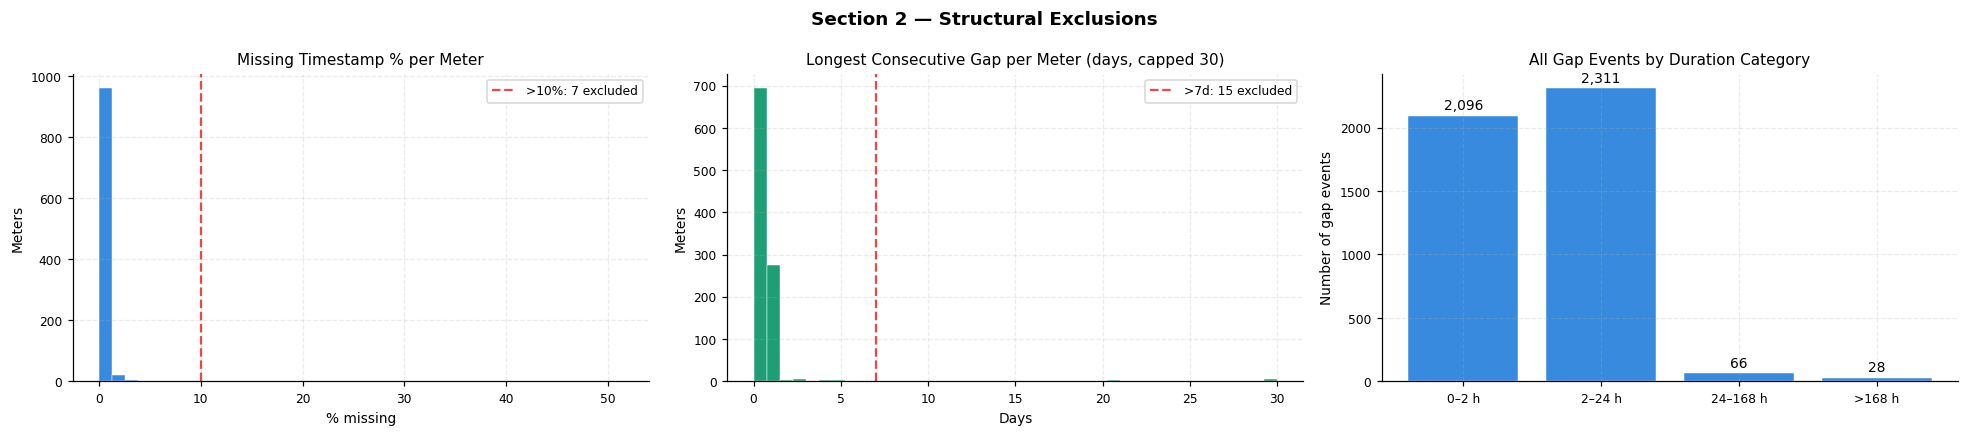

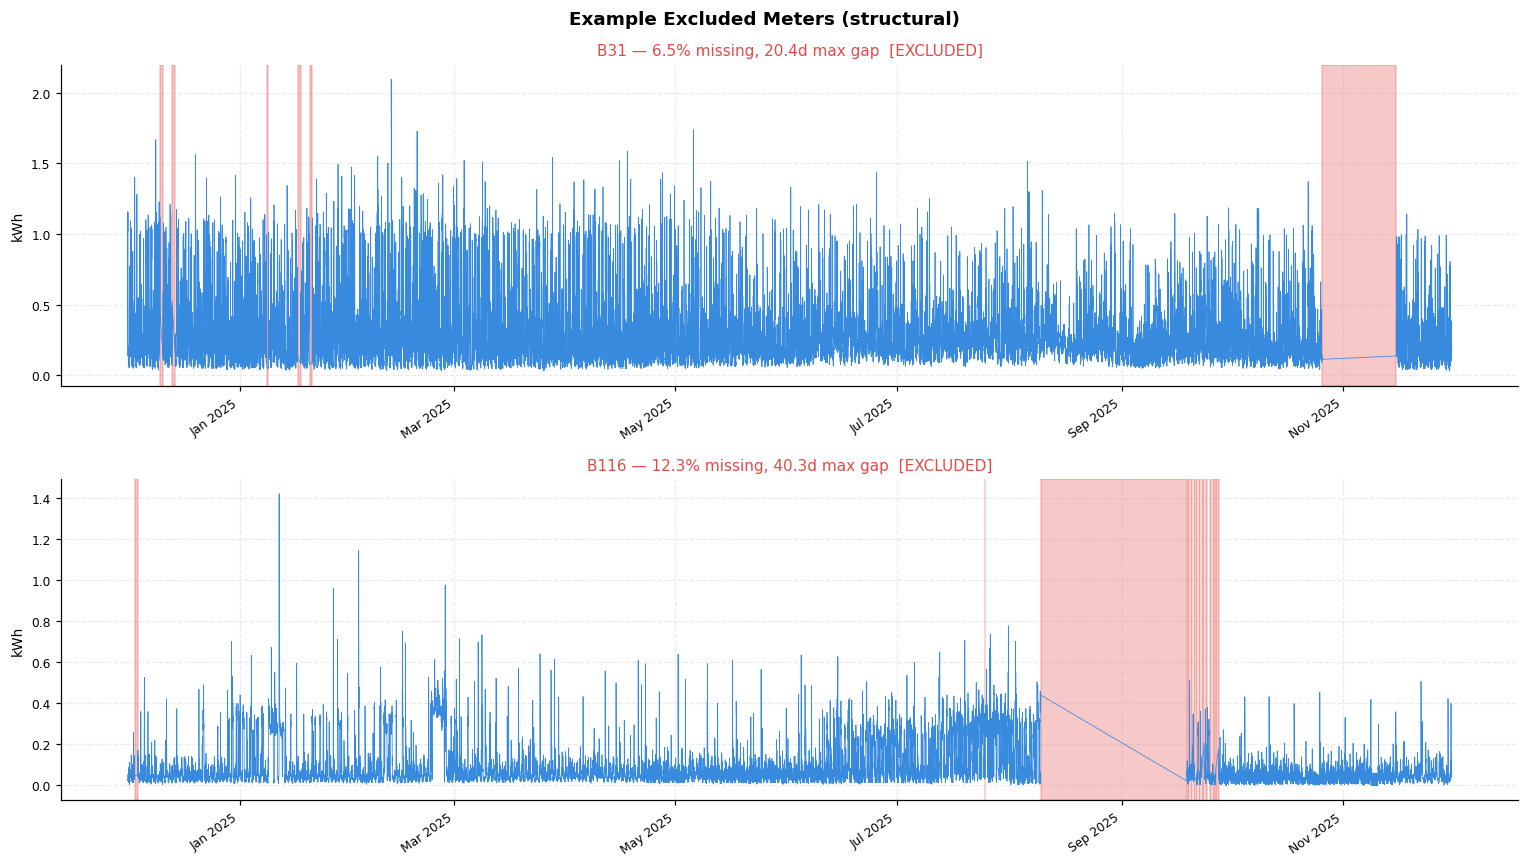


After structural exclusions: 984 meters, 17,186,160 rows


In [10]:
# =============================================================================
# SECTION 2 — Structural exclusions
# (>10% total missing  OR  >7-day consecutive gap)
# =============================================================================

print("\n" + "=" * 60)
print("SECTION 2 — Structural Exclusions")
print("=" * 60)

TOTAL_SLOTS = df["freeze_date"].nunique()
meter_counts = df.groupby("meter_B")["freeze_date"].nunique()
missing_pct  = (1 - meter_counts / TOTAL_SLOTS) * 100

# consecutive gap per meter
df_s = df.sort_values(["meter_B","freeze_date"])
df_s["_diff_h"] = (df_s.groupby("meter_B")["freeze_date"]
                       .diff().dt.total_seconds() / 3600 - 0.5)
max_gap_h = df_s.groupby("meter_B")["_diff_h"].max()
max_gap_d = max_gap_h / 24

excl_miss = sorted(missing_pct[missing_pct > THRESH_TOTAL_MISSING_PCT].index.tolist(),
                   key=lambda x: int(x[1:]))
excl_gap  = sorted(max_gap_h[max_gap_h > THRESH_CONSEC_GAP_HRS].index.tolist(),
                   key=lambda x: int(x[1:]))
struct_excl = sorted(set(excl_miss) | set(excl_gap), key=lambda x: int(x[1:]))

print(f"  >{THRESH_TOTAL_MISSING_PCT:.0f}% total missing   : {len(excl_miss)} meters")
print(f"  >{THRESH_CONSEC_GAP_HRS/24:.0f}d consecutive gap : {len(excl_gap)} meters")
print(f"  Total excluded          : {len(struct_excl)} meters")
print(f"  Retained                : {df['meter_B'].nunique() - len(struct_excl)} meters")

# ── gap event breakdown ───────────────────────────────────────────────────────
raw_gaps = df_s[df_s["_diff_h"] > 0].copy()
gap_dist = pd.cut(raw_gaps["_diff_h"],
                  bins=[0, 2, 24, 168, 99999],
                  labels=["0–2 h","2–24 h","24–168 h",">168 h"]).value_counts().sort_index()

# ── plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("Section 2 — Structural Exclusions", fontweight="bold")

axes[0].hist(missing_pct, bins=40, color=C_BLUE, edgecolor="white", lw=0.3)
axes[0].axvline(THRESH_TOTAL_MISSING_PCT, color=C_RED, lw=1.5, ls="--",
                label=f">{THRESH_TOTAL_MISSING_PCT:.0f}%: {len(excl_miss)} excluded")
axes[0].set_title("Missing Timestamp % per Meter")
axes[0].set_xlabel("% missing")
axes[0].set_ylabel("Meters")
axes[0].legend()

axes[1].hist(max_gap_d.clip(upper=30), bins=40, color=C_TEAL, edgecolor="white", lw=0.3)
axes[1].axvline(THRESH_CONSEC_GAP_HRS/24, color=C_RED, lw=1.5, ls="--",
                label=f">{THRESH_CONSEC_GAP_HRS/24:.0f}d: {len(excl_gap)} excluded")
axes[1].set_title("Longest Consecutive Gap per Meter (days, capped 30)")
axes[1].set_xlabel("Days")
axes[1].set_ylabel("Meters")
axes[1].legend()

bars2 = axes[2].bar(gap_dist.index, gap_dist.values, color=C_BLUE,
                    edgecolor="white", lw=0.3)
for b, v in zip(bars2, gap_dist.values):
    axes[2].text(b.get_x()+b.get_width()/2, v+max(gap_dist.values)*0.01,
                 f"{v:,}", ha="center", va="bottom", fontsize=9)
axes[2].set_title("All Gap Events by Duration Category")
axes[2].set_ylabel("Number of gap events")

plt.tight_layout()
plt.show()

# ── example excluded meters ───────────────────────────────────────────────────
if struct_excl:
    show = struct_excl[:min(2, len(struct_excl))]
    fig, axes = plt.subplots(len(show), 1,
                             figsize=(14, 4*len(show)), sharex=False, squeeze=False)
    for ax, mid in zip(axes[:,0], show):
        m = df[df["meter_B"]==mid].sort_values("freeze_date")
        ax.plot(m["freeze_date"], m["A+KWH"], lw=0.5, color=C_BLUE)
        diffs = m["freeze_date"].diff()
        for idx in m.index[diffs > pd.Timedelta("2h")]:
            ge = m.loc[idx,"freeze_date"]
            p  = m.index.get_loc(idx)
            gs_start = m.iloc[p-1]["freeze_date"]
            ax.axvspan(gs_start, ge, alpha=0.3, color=C_RED)
        ax.set_title(f"{mid} — {missing_pct.get(mid,0):.1f}% missing, "
                     f"{max_gap_d.get(mid,0):.1f}d max gap  [EXCLUDED]",
                     color=C_RED)
        ax.set_ylabel("kWh")
        _fmt_xaxis(ax)
    plt.suptitle("Example Excluded Meters (structural)", fontweight="bold")
    plt.tight_layout()
    plt.show()

df = df[~df["meter_B"].isin(struct_excl)].copy()
print(f"\nAfter structural exclusions: {df['meter_B'].nunique()} meters, {len(df):,} rows")


SECTION 3 — Zero Consumption Exclusions
  >40% zeros          : 115 meters
  >7d consec zeros  : 179 meters
  Total zero excl         : 180 meters


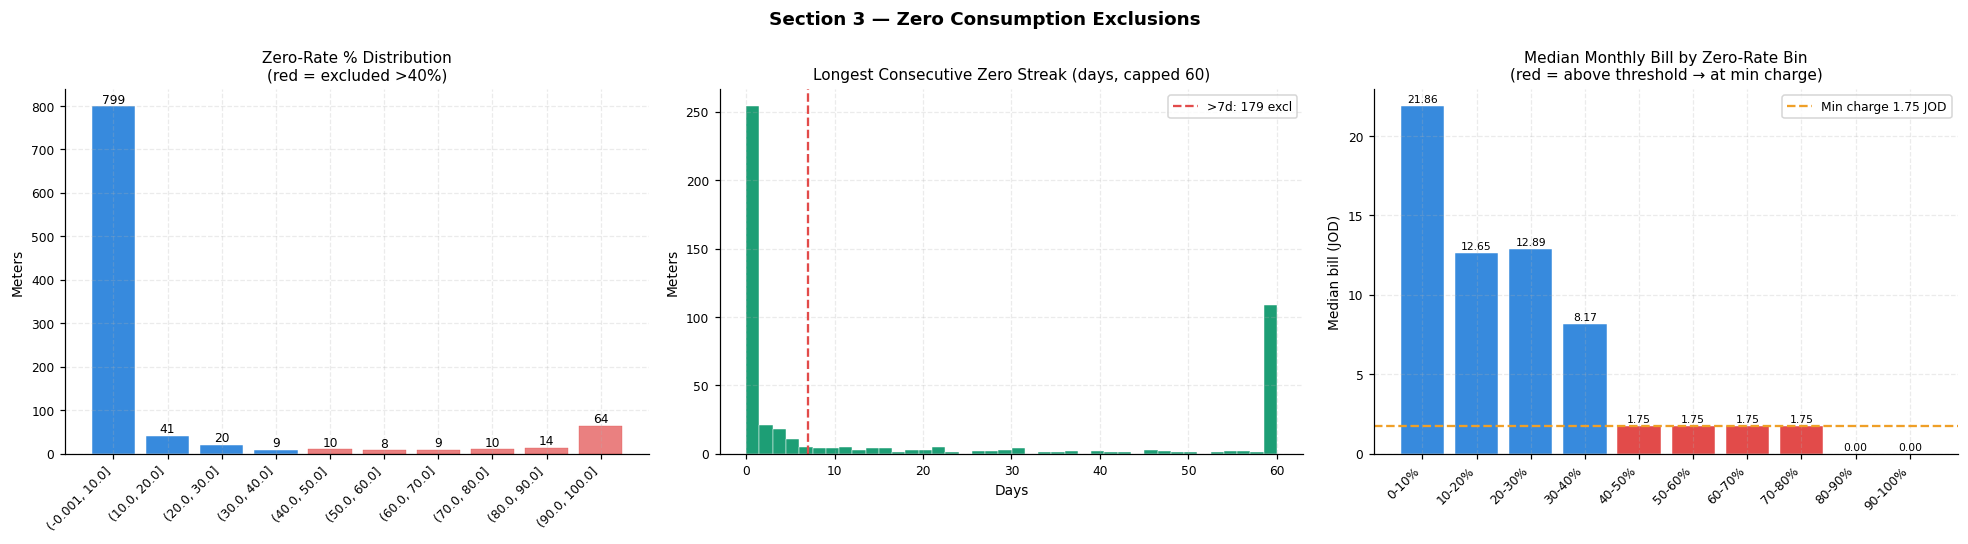

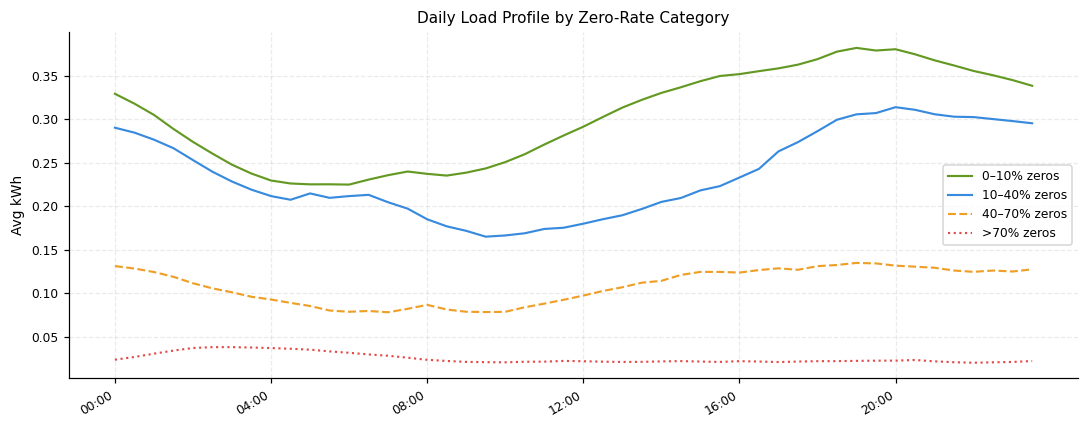


After zero exclusions: 804 meters, 14,040,778 rows


In [11]:
# =============================================================================
# SECTION 3 — Zero consumption exclusions
# (>40% zero readings  OR  >7-day consecutive zero streak)
# =============================================================================

print("\n" + "=" * 60)
print("SECTION 3 — Zero Consumption Exclusions")
print("=" * 60)

zero_rates = df.groupby("meter_B")["A+KWH"].apply(lambda x: (x == 0).mean() * 100)

is_zero   = (df["A+KWH"] == 0).astype(int)
streak_id = (is_zero != is_zero.groupby(df["meter_B"]).shift()).cumsum()
max_streak_h = (df[df["A+KWH"] == 0]
                .groupby(["meter_B", streak_id]).size()
                .groupby(level=0).max()
                .mul(0.5))  # slots × 0.5 h = hours

excl_high_zero  = sorted(zero_rates[zero_rates > THRESH_ZERO_RATE_PCT].index.tolist(),
                         key=lambda x: int(x[1:]))
excl_long_zero  = sorted(max_streak_h[max_streak_h > THRESH_CONSEC_ZERO_HRS].index.tolist(),
                         key=lambda x: int(x[1:]))
zero_excl = sorted(set(excl_high_zero) | set(excl_long_zero), key=lambda x: int(x[1:]))

print(f"  >{THRESH_ZERO_RATE_PCT:.0f}% zeros          : {len(excl_high_zero)} meters")
print(f"  >{THRESH_CONSEC_ZERO_HRS/24:.0f}d consec zeros  : {len(excl_long_zero)} meters")
print(f"  Total zero excl         : {len(zero_excl)} meters")

# billing cliff validation
df["_ym"] = df["freeze_date"].dt.to_period("M")
monthly = df.groupby(["meter_B","_ym"])["A+KWH"].sum().reset_index(name="monthly_kwh")
monthly["bill_jod"] = monthly["monthly_kwh"].apply(calc_bill_jod)
zr_bin_map = pd.cut(zero_rates,
                    bins=[0,10,20,30,40,50,60,70,80,90,100],
                    include_lowest=True,
                    labels=["0-10","10-20","20-30","30-40","40-50",
                            "50-60","60-70","70-80","80-90","90-100"])
monthly["zr_bin"] = monthly["meter_B"].map(zr_bin_map)
bill_cliff = monthly.groupby("zr_bin", observed=True)["bill_jod"].median()
df.drop(columns=["_ym"], inplace=True, errors="ignore")

# ── plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Section 3 — Zero Consumption Exclusions", fontweight="bold")

bins_pct = list(range(0, 101, 10))
zr_binned = pd.cut(zero_rates, bins=bins_pct, include_lowest=True)
zr_counts = zr_binned.value_counts().sort_index()
bars0 = axes[0].bar(range(len(zr_counts)), zr_counts.values,
                    color=C_BLUE, edgecolor="white", lw=0.3)
for i, (b, v) in enumerate(zip(bars0, zr_counts.values)):
    if v > 0:
        axes[0].text(b.get_x()+b.get_width()/2, v+0.5, str(v),
                     ha="center", va="bottom", fontsize=8)
thresh_bin = int(THRESH_ZERO_RATE_PCT // 10)
for b in bars0[thresh_bin:]:
    b.set_color(C_RED); b.set_alpha(0.7)
axes[0].set_xticks(range(len(zr_counts)))
axes[0].set_xticklabels([str(i) for i in zr_binned.cat.categories],
                         rotation=45, ha="right")
axes[0].set_title(f"Zero-Rate % Distribution\n(red = excluded >{THRESH_ZERO_RATE_PCT:.0f}%)")
axes[0].set_ylabel("Meters")

axes[1].hist((max_streak_h/24).clip(upper=60), bins=40, color=C_TEAL,
             edgecolor="white", lw=0.3)
axes[1].axvline(THRESH_CONSEC_ZERO_HRS/24, color=C_RED, lw=1.5, ls="--",
                label=f">{THRESH_CONSEC_ZERO_HRS/24:.0f}d: {len(excl_long_zero)} excl")
axes[1].set_title("Longest Consecutive Zero Streak (days, capped 60)")
axes[1].set_xlabel("Days")
axes[1].set_ylabel("Meters")
axes[1].legend()

bars_bc = axes[2].bar(range(len(bill_cliff)), bill_cliff.values,
                      color=[C_RED if i >= thresh_bin else C_BLUE
                             for i in range(len(bill_cliff))],
                      edgecolor="white", lw=0.3)
for b, v in zip(bars_bc, bill_cliff.values):
    axes[2].text(b.get_x()+b.get_width()/2, v+0.1, f"{v:.2f}",
                 ha="center", va="bottom", fontsize=7)
axes[2].axhline(MIN_CHARGE_JOD, color=C_AMBER, lw=1.5, ls="--",
                label=f"Min charge {MIN_CHARGE_JOD} JOD")
axes[2].set_xticks(range(len(bill_cliff)))
axes[2].set_xticklabels([f"{b}%" for b in bill_cliff.index], rotation=45, ha="right")
axes[2].set_title("Median Monthly Bill by Zero-Rate Bin\n"
                  "(red = above threshold → at min charge)")
axes[2].set_ylabel("Median bill (JOD)")
axes[2].legend()

plt.tight_layout()
plt.show()

# ── load profiles by zero rate category ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
slot_col = df["freeze_date"].dt.hour*2 + (df["freeze_date"].dt.minute==30).astype(int)
for label, mask, color, ls in [
    ("0–10% zeros",   zero_rates <= 10,                          C_GREEN, "-"),
    ("10–40% zeros",  (zero_rates>10) & (zero_rates<=40),        C_BLUE,  "-"),
    ("40–70% zeros",  (zero_rates>40) & (zero_rates<=70),        C_AMBER, "--"),
    (">70% zeros",    zero_rates > 70,                           C_RED,   ":"),
]:
    mids = zero_rates[mask].index
    sub  = df[df["meter_B"].isin(mids)]
    if not sub.empty:
        sc = sub["freeze_date"].dt.hour*2 + (sub["freeze_date"].dt.minute==30).astype(int)
        c  = sub.groupby(sc)["A+KWH"].mean()
        ax.plot(range(48), c.reindex(range(48), fill_value=0).values,
                lw=1.4, ls=ls, label=label, color=color)
_slot_xticks(ax, step=8)
ax.set_title("Daily Load Profile by Zero-Rate Category")
ax.set_ylabel("Avg kWh")
ax.legend()
plt.tight_layout()
plt.show()

df = df[~df["meter_B"].isin(zero_excl)].copy()
print(f"\nAfter zero exclusions: {df['meter_B'].nunique()} meters, {len(df):,} rows")

In [12]:
# =============================================================================
# SECTION 5 — Grid rebuild (fill missing timestamps with NaN)
# =============================================================================

print("\n" + "=" * 60)
print("SECTION 5 — Grid Rebuild")
print("=" * 60)

global_start = df["freeze_date"].min()
global_end   = df["freeze_date"].max()
meters       = df["meter_B"].unique()

grid_rows = [(m, t)
             for m in meters
             for t in pd.date_range(global_start, global_end, freq="30min")]

df_grid = pd.merge(
    pd.DataFrame(grid_rows, columns=["meter_B","freeze_date"]),
    df[["meter_B","freeze_date","A+KWH"]],
    on=["meter_B","freeze_date"], how="left"
)
df_grid = df_grid.sort_values(["meter_B","freeze_date"]).reset_index(drop=True)

n_nan = int(df_grid["A+KWH"].isna().sum())
print(f"  Grid rows    : {len(df_grid):,}")
print(f"  NaN before   : {n_nan:,}  ({n_nan/len(df_grid)*100:.2f}%)")

# snapshot before imputation
df_before_grid = df_grid[["meter_B","freeze_date","A+KWH"]].copy()
del df; gc.collect()



SECTION 5 — Grid Rebuild
  Grid rows    : 14,086,080
  NaN before   : 45,302  (0.32%)


0

In [13]:
# =============================================================================
# SECTION 6 — Three-mode imputation
#
#   Mode A:  0–2 h   (≤4 slots)    -> linear interpolation
#   Mode B:  2–24 h  (5–48 slots)  -> seasonal median (same slot, same DoW)
#   Mode C:  24–168 h (49–336 slots) -> seasonal KNN   (same slot, same DoW, k=5)
#
# Slots with gaps >168 h were already excluded in Section 2.
# =============================================================================

print("\n" + "=" * 60)
print("SECTION 6 — Three-Mode Imputation")
print("=" * 60)

from sklearn.impute import KNNImputer

_LIN_MAX  = 4    # ≤4 slots = 0–2 h
_SEAS_MAX = 48   # ≤48 slots = 2–24 h
_KNN_MAX  = 336  # ≤336 slots = 24–168 h

# ── imputation helpers ────────────────────────────────────────────────────────

def _seasonal_median(vals, nan_pos, slots_per_day=48, weeks=8):
    """Fill nan_pos using same-slot same-DoW look-back up to `weeks` weeks."""
    out  = vals.copy()
    step = slots_per_day * 7
    for pos in nan_pos:
        lb = [out[pos - w*step] for w in range(1, weeks+1)
              if pos - w*step >= 0 and not np.isnan(out[pos - w*step])]
        if lb:
            out[pos] = float(np.median(lb)); continue
        ss = pos % slots_per_day
        sv = [out[i] for i in range(ss, len(out), slots_per_day) if not np.isnan(out[i])]
        if sv:
            out[pos] = float(np.median(sv)); continue
        gm = np.nanmedian(out)
        if not np.isnan(gm):
            out[pos] = float(gm)
    return out


def _seasonal_knn(vals, nan_pos, slots_per_day=48, weeks=8, k=5):
    """Fill nan_pos using KNN over same (slot, DoW) from prior weeks."""
    out  = vals.copy()
    step = slots_per_day * 7
    for pos in nan_pos:
        candidates = []
        for w in range(1, weeks+1):
            ref = pos - w * step
            if ref >= 0 and not np.isnan(out[ref]):
                candidates.append([out[ref]])
        if len(candidates) < 2:
            # fallback to median
            ss = pos % slots_per_day
            sv = [out[i] for i in range(ss, len(out), slots_per_day) if not np.isnan(out[i])]
            out[pos] = float(np.median(sv)) if sv else float(np.nanmedian(out))
            continue
        X    = np.array(candidates)
        data = np.vstack([X, [[np.nan]]])
        imp  = KNNImputer(n_neighbors=min(k, len(X)))
        out[pos] = float(imp.fit_transform(data)[-1, 0])
    return out


# ── main imputation loop ──────────────────────────────────────────────────────

df_grid["is_imputed"]          = df_grid["A+KWH"].isna().astype("int8")
df_grid["is_imputed_linear"]   = np.int8(0)
df_grid["is_imputed_seasonal"] = np.int8(0)
df_grid["is_imputed_knn"]      = np.int8(0)

parts    = []
cnt_lin  = cnt_sea = cnt_knn = 0
n_meters = df_grid["meter_B"].nunique()

for i_m, (mid, g) in enumerate(df_grid.groupby("meter_B", sort=False)):
    if (i_m + 1) % max(1, n_meters // 10) == 0:
        print(f"  imputing meter {i_m+1}/{n_meters} ...", flush=True)

    g = g.copy().reset_index(drop=True)

    nan_flag = g["A+KWH"].isna().astype(int)
    run_id   = (nan_flag != nan_flag.shift()).cumsum()
    run_len  = nan_flag.groupby(run_id).transform("sum")

    # ── MODE A: linear (0–2 h, ≤4 slots) ─────────────────────────────────────
    lin_mask = (nan_flag == 1) & (run_len <= _LIN_MAX)
    if lin_mask.any():
        g["A+KWH"] = g["A+KWH"].interpolate(
            method="linear", limit=_LIN_MAX, limit_direction="both")
        filled = lin_mask & g["A+KWH"].notna()
        g.loc[filled, "is_imputed_linear"] = np.int8(1)
        cnt_lin += int(filled.sum())

    # ── MODE B: seasonal median (2–24 h, 5–48 slots) ─────────────────────────
    sea_mask = g["A+KWH"].isna() & (run_len > _LIN_MAX) & (run_len <= _SEAS_MAX)
    if sea_mask.any():
        vals    = g["A+KWH"].values.copy()
        nan_pos = np.where(sea_mask)[0]
        vals    = _seasonal_median(vals, nan_pos, weeks=8)
        for pos in nan_pos:
            if not np.isnan(vals[pos]):
                g.at[pos, "A+KWH"]              = vals[pos]
                g.at[pos, "is_imputed_seasonal"] = np.int8(1)
                cnt_sea += 1

    # ── MODE C: seasonal KNN (24–168 h, 49–336 slots) ────────────────────────
    knn_mask = g["A+KWH"].isna() & (run_len > _SEAS_MAX) & (run_len <= _KNN_MAX)
    if knn_mask.any():
        vals    = g["A+KWH"].values.copy()
        nan_pos = np.where(knn_mask)[0]
        vals    = _seasonal_knn(vals, nan_pos, weeks=8, k=5)
        for pos in nan_pos:
            if not np.isnan(vals[pos]):
                g.at[pos, "A+KWH"]          = vals[pos]
                g.at[pos, "is_imputed_knn"] = np.int8(1)
                cnt_knn += 1

    parts.append(g)

df_grid = pd.concat(parts, ignore_index=True)
df_grid["A+KWH"] = df_grid["A+KWH"].clip(lower=0).astype("float32")

print(f"\n  Mode A linear    (0–2 h)    : {cnt_lin:>8,} slots")
print(f"  Mode B seasonal  (2–24 h)   : {cnt_sea:>8,} slots")
print(f"  Mode C KNN       (24–168 h) : {cnt_knn:>8,} slots")
print(f"  NaN remaining               : {df_grid['A+KWH'].isna().sum()} (should be 0)")


SECTION 6 — Three-Mode Imputation
  imputing meter 80/804 ...
  imputing meter 160/804 ...
  imputing meter 240/804 ...
  imputing meter 320/804 ...
  imputing meter 400/804 ...
  imputing meter 480/804 ...
  imputing meter 560/804 ...
  imputing meter 640/804 ...
  imputing meter 720/804 ...
  imputing meter 800/804 ...

  Mode A linear    (0–2 h)    :    3,759 slots
  Mode B seasonal  (2–24 h)   :   22,541 slots
  Mode C KNN       (24–168 h) :    6,506 slots
  NaN remaining               : 0 (should be 0)



SECTION 7 — Imputation Quality Visuals


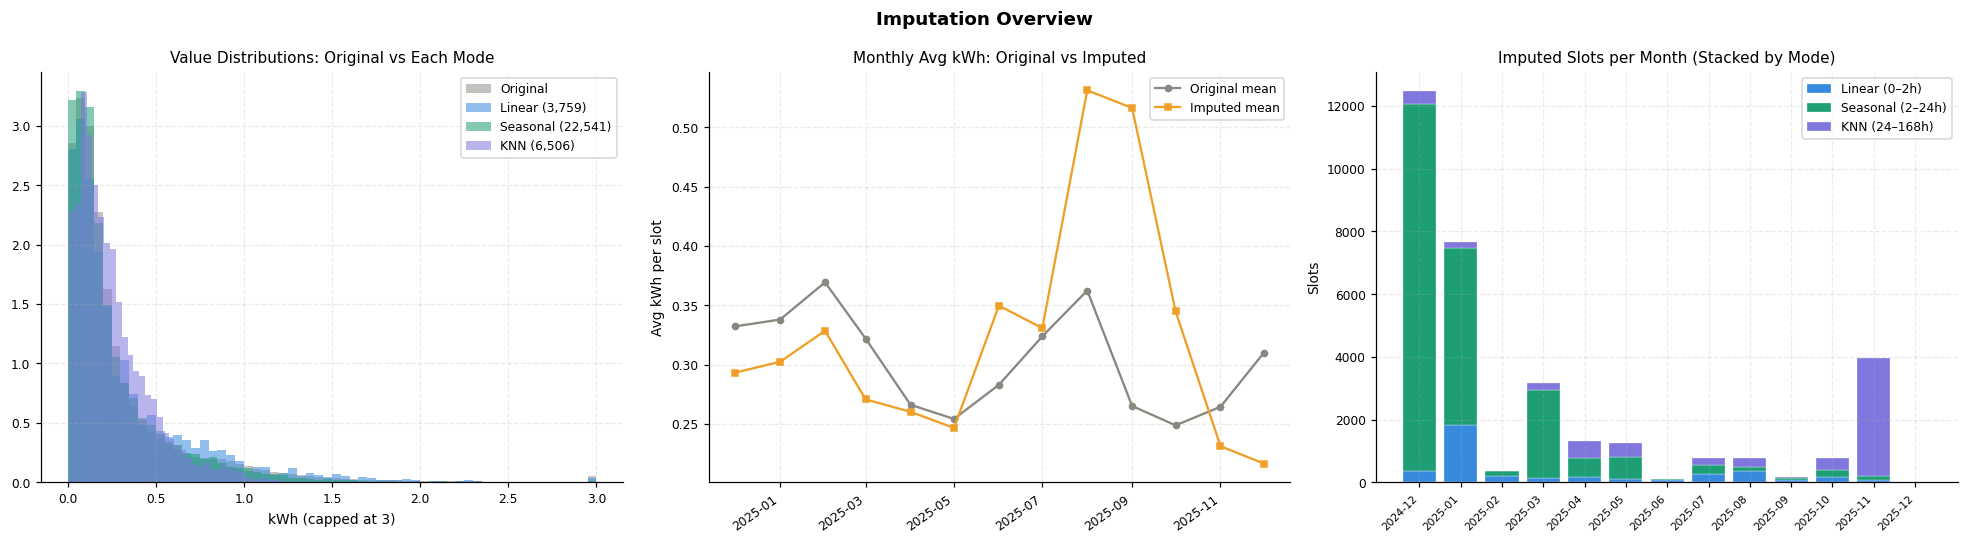

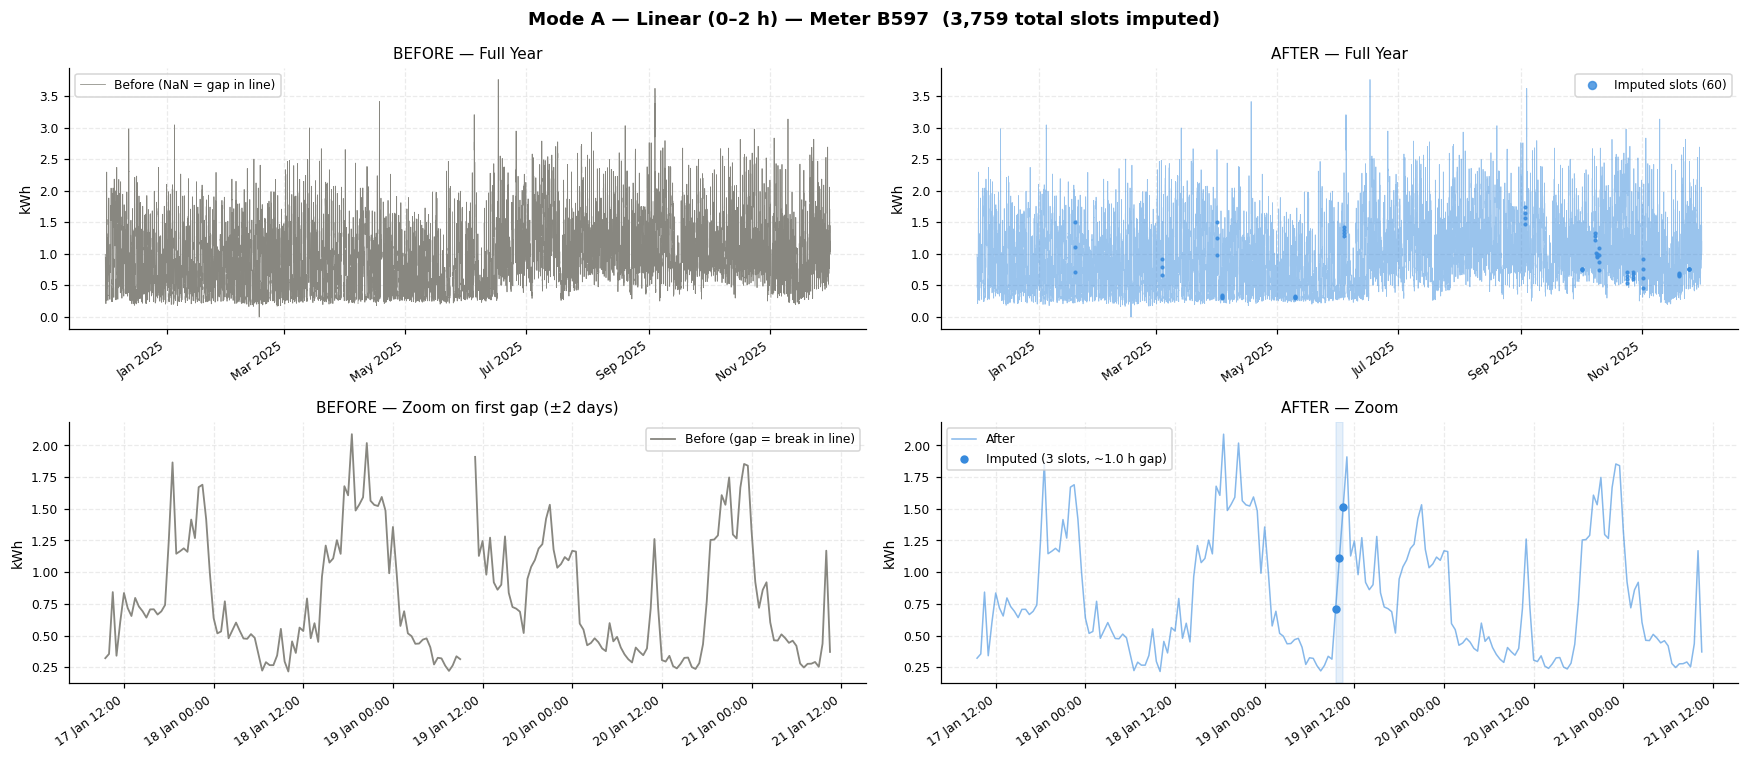

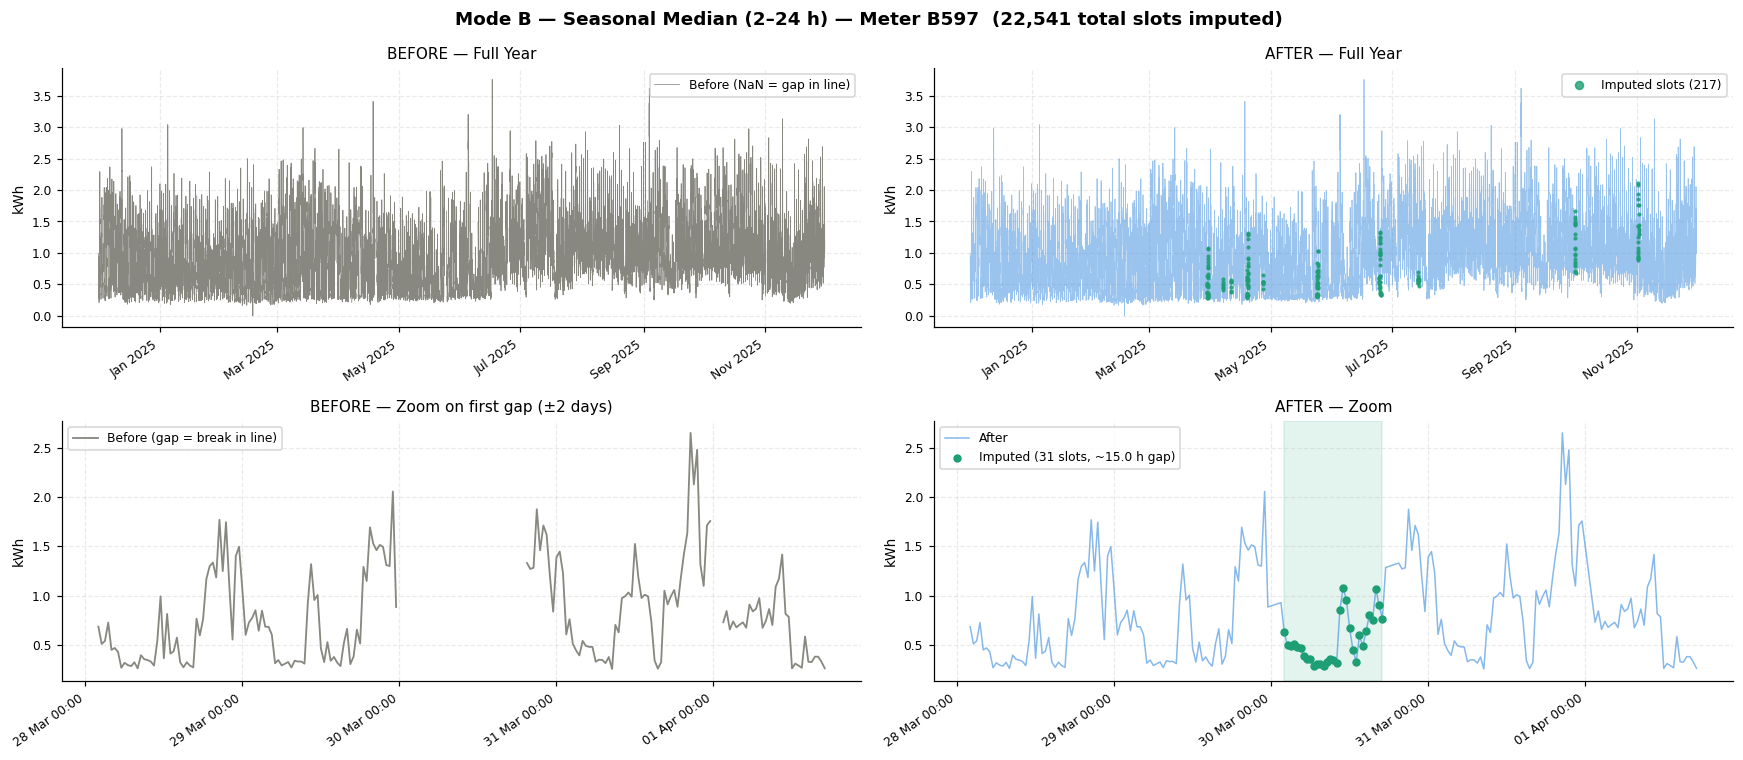

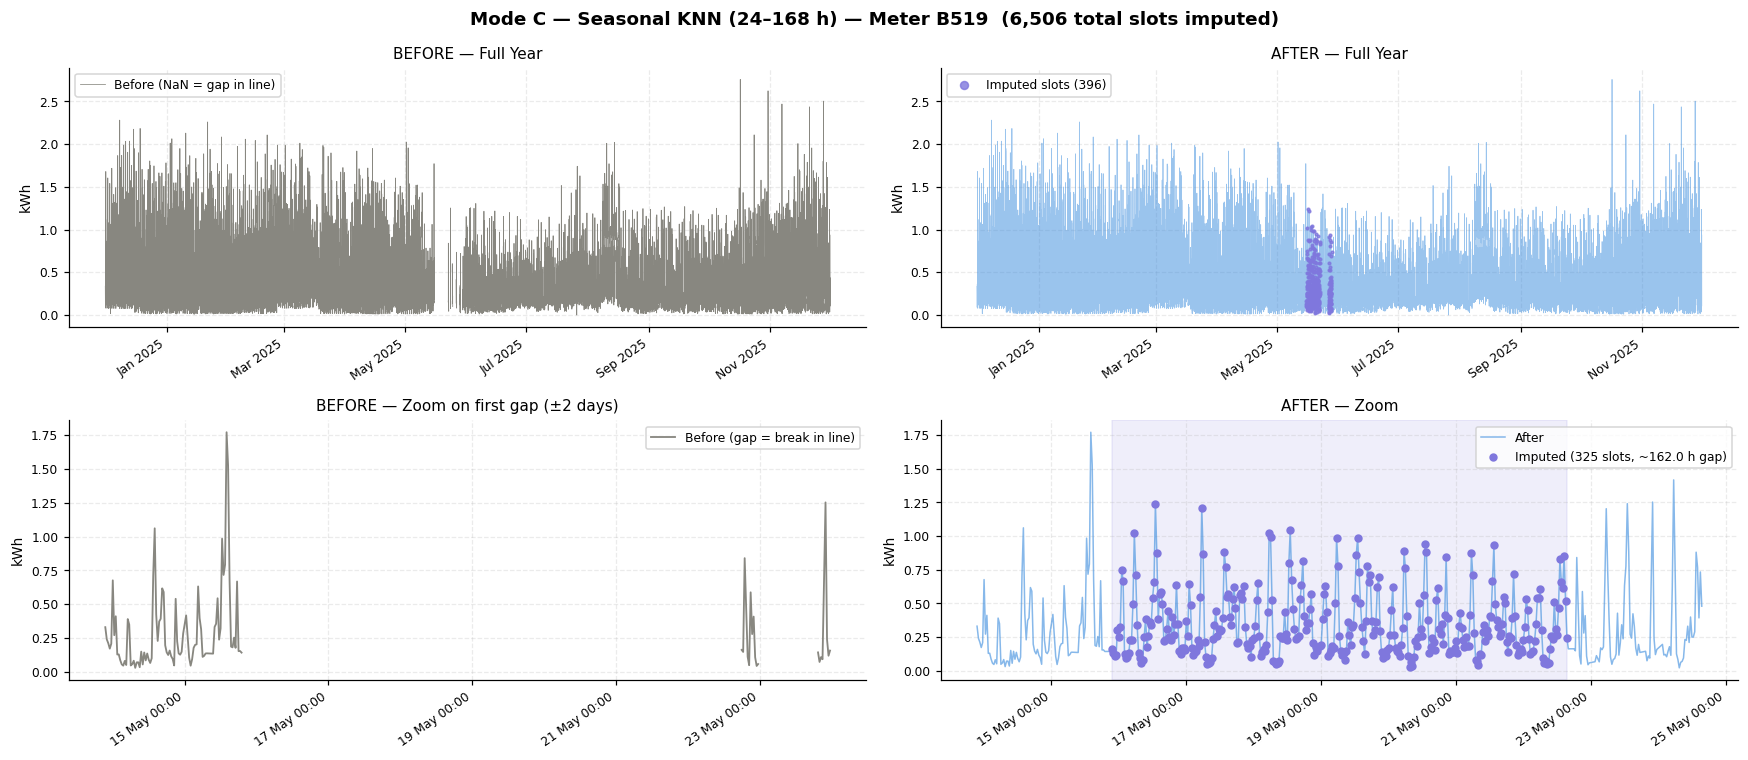

In [14]:
# =============================================================================
# SECTION 7 — Imputation quality visuals
# (distribution + monthly + before/after zoom for each mode)
# =============================================================================

print("\n" + "=" * 60)
print("SECTION 7 — Imputation Quality Visuals")
print("=" * 60)

# ── overview: distributions + monthly stacked + mode counts ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Imputation Overview", fontweight="bold")

orig_vals = df_before_grid["A+KWH"].dropna()
lin_vals  = df_grid[df_grid["is_imputed_linear"]   == 1]["A+KWH"]
sea_vals  = df_grid[df_grid["is_imputed_seasonal"]  == 1]["A+KWH"]
knn_vals  = df_grid[df_grid["is_imputed_knn"]       == 1]["A+KWH"]

axes[0].hist(orig_vals.clip(0, 3), bins=60, alpha=0.5, color=C_GRAY,
             density=True, label=f"Original")
if len(lin_vals):
    axes[0].hist(lin_vals.clip(0, 3), bins=60, alpha=0.55, color=C_BLUE,
                 density=True, label=f"Linear ({cnt_lin:,})")
if len(sea_vals):
    axes[0].hist(sea_vals.clip(0, 3), bins=60, alpha=0.55, color=C_TEAL,
                 density=True, label=f"Seasonal ({cnt_sea:,})")
if len(knn_vals):
    axes[0].hist(knn_vals.clip(0, 3), bins=60, alpha=0.55, color=C_PURPL,
                 density=True, label=f"KNN ({cnt_knn:,})")
axes[0].set_title("Value Distributions: Original vs Each Mode")
axes[0].set_xlabel("kWh (capped at 3)")
axes[0].legend()

# monthly mean original vs imputed
period_col  = df_grid["freeze_date"].dt.to_period("M")
m_orig = df_grid[df_grid["is_imputed"]==0].groupby(period_col)["A+KWH"].mean()
m_impu = df_grid[df_grid["is_imputed"]==1].groupby(period_col)["A+KWH"].mean()
axes[1].plot(m_orig.index.to_timestamp(), m_orig.values,
             lw=1.5, color=C_GRAY, marker="o", markersize=4, label="Original mean")
axes[1].plot(m_impu.index.to_timestamp(), m_impu.values,
             lw=1.5, color=C_AMBER, marker="s", markersize=4, label="Imputed mean")
axes[1].set_title("Monthly Avg kWh: Original vs Imputed")
axes[1].set_ylabel("Avg kWh per slot")
axes[1].legend()
plt.setp(axes[1].get_xticklabels(), rotation=35, ha="right")

# stacked bar per month
all_periods = sorted(period_col.unique())
lin_pm  = df_grid[df_grid["is_imputed_linear"]   ==1].groupby(period_col).size()
sea_pm  = df_grid[df_grid["is_imputed_seasonal"]  ==1].groupby(period_col).size()
knn_pm  = df_grid[df_grid["is_imputed_knn"]       ==1].groupby(period_col).size()
xpos = range(len(all_periods))
lv = [lin_pm.get(p,0) for p in all_periods]
sv = [sea_pm.get(p,0) for p in all_periods]
kv = [knn_pm.get(p,0) for p in all_periods]
axes[2].bar(xpos, lv, label="Linear (0–2h)",   color=C_BLUE,  edgecolor="white", lw=0.2)
axes[2].bar(xpos, sv, bottom=lv, label="Seasonal (2–24h)", color=C_TEAL,  edgecolor="white", lw=0.2)
bot2 = [a+b for a,b in zip(lv,sv)]
axes[2].bar(xpos, kv, bottom=bot2, label="KNN (24–168h)",   color=C_PURPL, edgecolor="white", lw=0.2)
axes[2].set_xticks(range(len(all_periods)))
axes[2].set_xticklabels([str(p) for p in all_periods], rotation=45, ha="right", fontsize=7)
axes[2].set_title("Imputed Slots per Month (Stacked by Mode)")
axes[2].set_ylabel("Slots")
axes[2].legend()

plt.tight_layout()
plt.show()

# ── before / after zoom: one panel per mode ───────────────────────────────────
mode_specs = [
    ("is_imputed_linear",   "Mode A — Linear (0–2 h)",          C_BLUE,  cnt_lin),
    ("is_imputed_seasonal", "Mode B — Seasonal Median (2–24 h)", C_TEAL,  cnt_sea),
    ("is_imputed_knn",      "Mode C — Seasonal KNN (24–168 h)",  C_PURPL, cnt_knn),
]

for imp_col, mode_label, color, total_cnt in mode_specs:
    meter_id = df_grid.groupby("meter_B")[imp_col].sum().idxmax() \
               if total_cnt > 0 else None
    if meter_id is None:
        print(f"  {mode_label}: no imputed slots found, skipping.")
        continue

    mb  = df_before_grid[df_before_grid["meter_B"]==meter_id].sort_values("freeze_date")
    ma  = df_grid[df_grid["meter_B"]==meter_id].sort_values("freeze_date")
    imp_rows = ma[ma[imp_col] == 1]
    if imp_rows.empty:
        continue

    # ── full year before/after ────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(16, 7))
    fig.suptitle(f"{mode_label} — Meter {meter_id}  ({total_cnt:,} total slots imputed)",
                 fontweight="bold")

    axes[0,0].plot(mb["freeze_date"], mb["A+KWH"], lw=0.5, color=C_GRAY,
                   label="Before (NaN = gap in line)")
    axes[0,0].set_title("BEFORE — Full Year")
    axes[0,0].set_ylabel("kWh")
    axes[0,0].legend()
    _fmt_xaxis(axes[0,0])

    axes[0,1].plot(ma["freeze_date"], ma["A+KWH"], lw=0.5, color=C_BLUE, alpha=0.5)
    axes[0,1].scatter(imp_rows["freeze_date"], imp_rows["A+KWH"],
                      s=3, color=color, alpha=0.8, zorder=4,
                      label=f"Imputed slots ({len(imp_rows):,})")
    axes[0,1].set_title("AFTER — Full Year")
    axes[0,1].set_ylabel("kWh")
    axes[0,1].legend(markerscale=3)
    _fmt_xaxis(axes[0,1])

    # ── zoom: find first gap run and zoom ±2 days ─────────────────────────────
    imp_dates   = imp_rows["freeze_date"].sort_values()
    first_start = imp_dates.iloc[0]
    run_end     = first_start
    for d in imp_dates:
        if (d - run_end) <= pd.Timedelta("30min"):
            run_end = d
        else:
            break
    gap_h = (run_end - first_start).total_seconds() / 3600
    zs = first_start - pd.Timedelta("2D")
    ze = run_end     + pd.Timedelta("2D")

    mbz = mb[(mb["freeze_date"] >= zs) & (mb["freeze_date"] <= ze)]
    maz = ma[(ma["freeze_date"] >= zs) & (ma["freeze_date"] <= ze)]
    imp_z = maz[maz[imp_col] == 1]

    axes[1,0].plot(mbz["freeze_date"], mbz["A+KWH"], lw=1.2, color=C_GRAY,
                   label="Before (gap = break in line)")
    axes[1,0].set_title(f"BEFORE — Zoom on first gap (±2 days)")
    axes[1,0].set_ylabel("kWh")
    axes[1,0].legend()
    axes[1,0].xaxis.set_major_formatter(mdates.DateFormatter("%d %b %H:%M"))
    plt.setp(axes[1,0].get_xticklabels(), rotation=35, ha="right")

    axes[1,1].plot(maz["freeze_date"], maz["A+KWH"], lw=1.0, color=C_BLUE,
                   alpha=0.6, label="After")
    if not imp_z.empty:
        axes[1,1].scatter(imp_z["freeze_date"], imp_z["A+KWH"],
                          s=20, color=color, zorder=5,
                          label=f"Imputed ({len(imp_z)} slots, ~{gap_h:.1f} h gap)")
        axes[1,1].axvspan(imp_z["freeze_date"].min(), imp_z["freeze_date"].max(),
                          alpha=0.12, color=color)
    axes[1,1].set_title(f"AFTER — Zoom")
    axes[1,1].set_ylabel("kWh")
    axes[1,1].legend()
    axes[1,1].xaxis.set_major_formatter(mdates.DateFormatter("%d %b %H:%M"))
    plt.setp(axes[1,1].get_xticklabels(), rotation=35, ha="right")

    plt.tight_layout()
    plt.show()


SECTION 8 — Calendar & Load Profile EDA


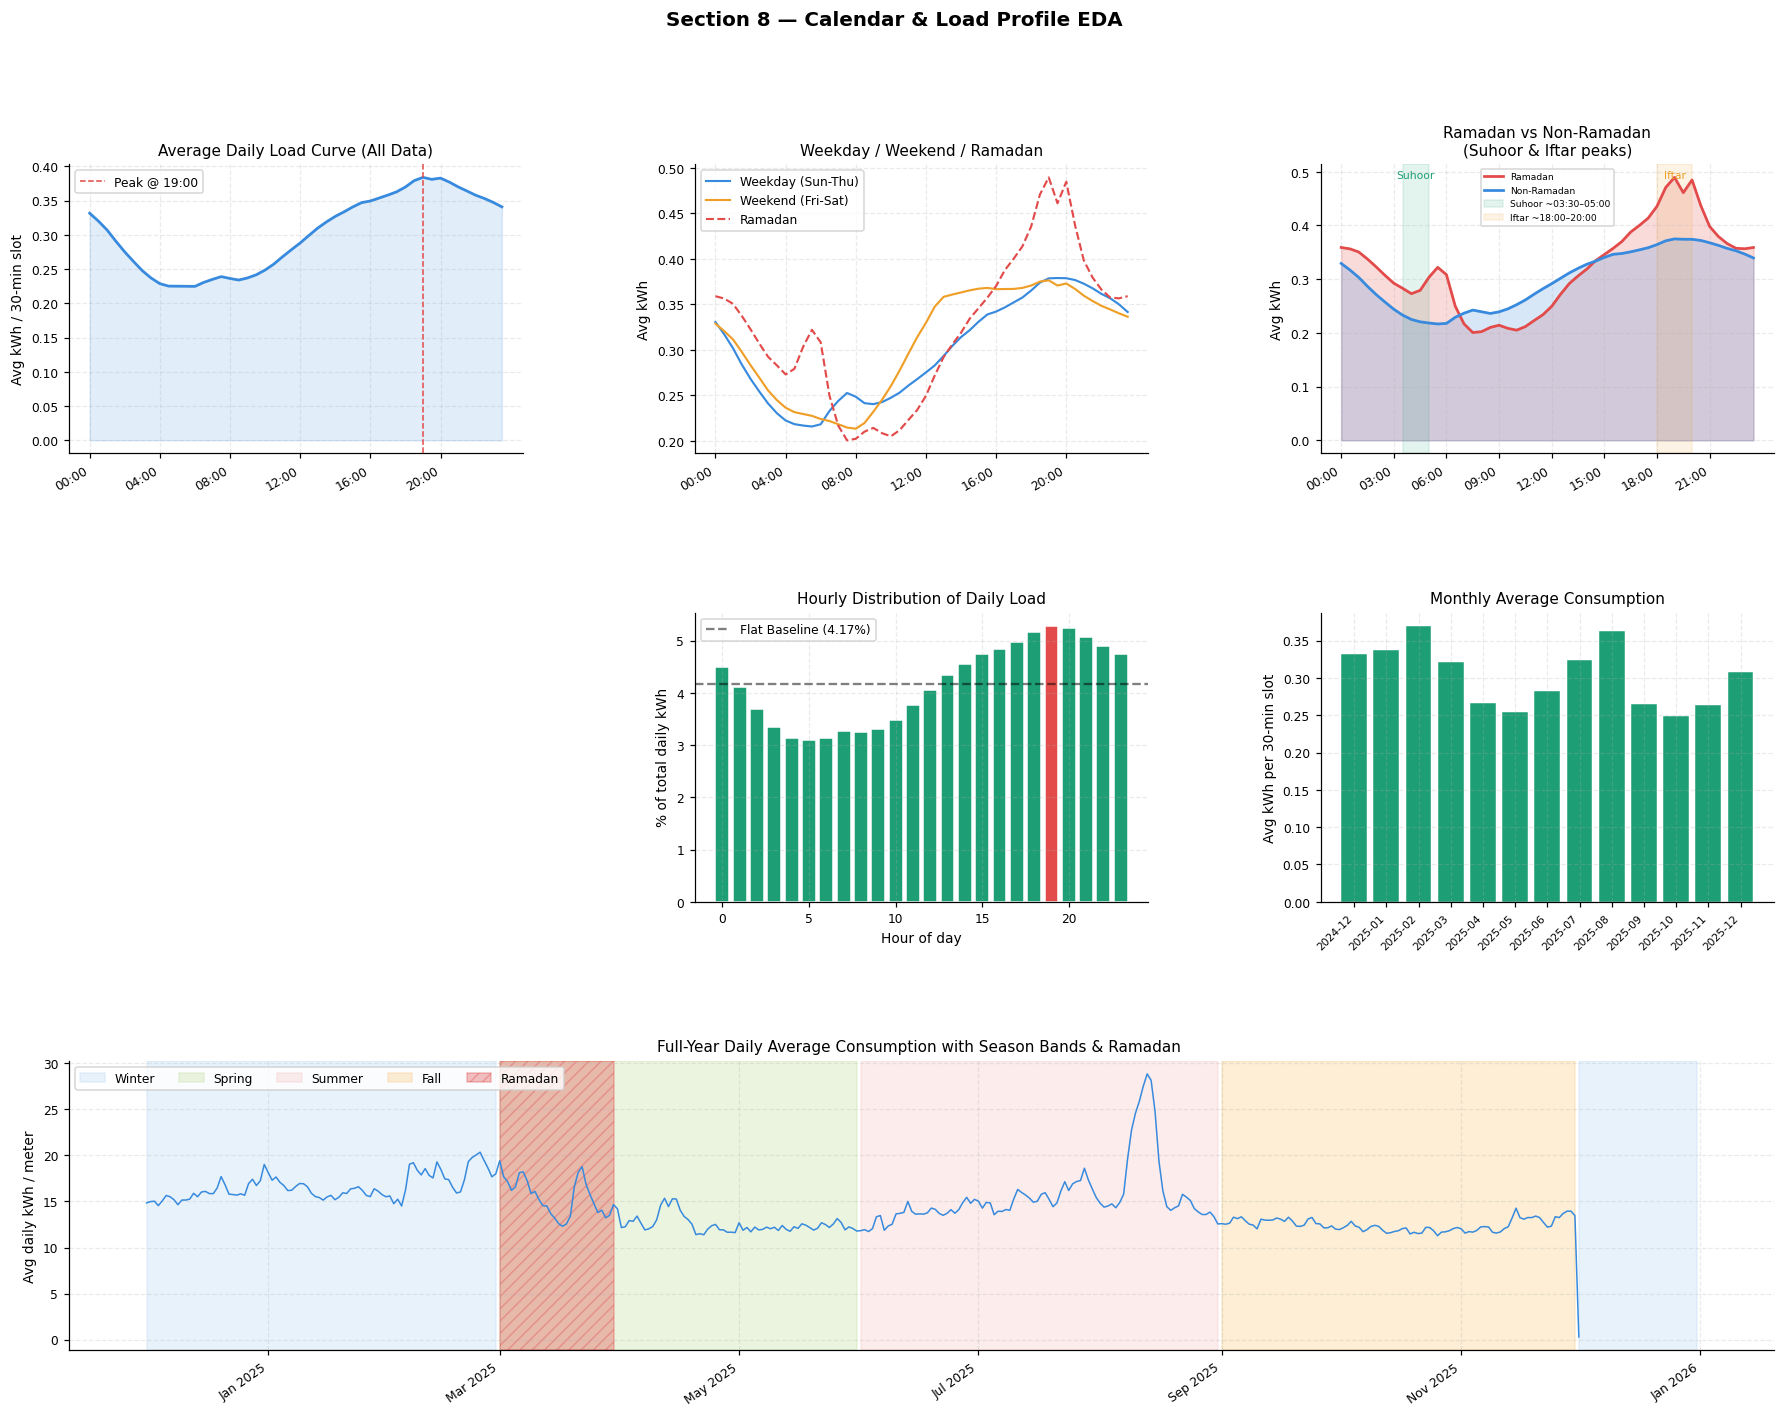

In [15]:
# =============================================================================
# SECTION 8 — Calendar & load profile EDA
# =============================================================================

print("\n" + "=" * 60)
print("SECTION 8 — Calendar & Load Profile EDA")
print("=" * 60)

df_grid["freeze_date"] = pd.to_datetime(df_grid["freeze_date"])
slot_col = df_grid["freeze_date"].dt.hour*2 + (df_grid["freeze_date"].dt.minute==30).astype(int)
hour_col = df_grid["freeze_date"].dt.hour

is_ram  = df_grid["freeze_date"].between(RAMADAN_START, RAMADAN_END)
is_wknd = df_grid["freeze_date"].dt.dayofweek.isin([4, 5])
is_wkdy = (~is_wknd) & (~is_ram)
is_biz  = df_grid["freeze_date"].dt.hour.between(8, 15) # 08:00 - 16:00

fig = plt.figure(figsize=(20, 14))
fig.suptitle("Section 8 — Calendar & Load Profile EDA", fontsize=13, fontweight="bold")
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.38)

# ── overall daily load ────────────────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, 0])
all_curve = df_grid.groupby(slot_col)["A+KWH"].mean()
ax0.fill_between(range(48), all_curve.reindex(range(48), fill_value=0).values,
                 alpha=0.15, color=C_BLUE)
ax0.plot(range(48), all_curve.reindex(range(48), fill_value=0).values,
         color=C_BLUE, lw=1.8)
pk = all_curve.idxmax()
ax0.axvline(pk, color=C_RED, lw=1, ls="--", label=f"Peak @ {SLOT_LABELS[pk]}")
_slot_xticks(ax0, step=8)
ax0.set_title("Average Daily Load Curve (All Data)")
ax0.set_ylabel("Avg kWh / 30-min slot")
ax0.legend()

# ── weekday / weekend / Ramadan  ─────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 1])
for grp, lbl, col, ls in [
    (is_wkdy, "Weekday (Sun-Thu)",  C_BLUE,  "-"),
    (is_wknd, "Weekend (Fri-Sat)",  C_AMBER, "-"),
    (is_ram,  "Ramadan",            C_RED,   "--")
]:
    sub = df_grid[grp]
    if not sub.empty:
        sc = slot_col[grp]
        c  = sub.groupby(sc)["A+KWH"].mean()
        ax1.plot(range(48), c.reindex(range(48), fill_value=np.nan).values,
                 lw=1.4, ls=ls, label=lbl, color=col)
_slot_xticks(ax1, step=8)
ax1.set_title("Weekday / Weekend / Ramadan")
ax1.set_ylabel("Avg kWh")
ax1.legend()

# ── Ramadan Iftar / Suhoor ────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
c_ram = df_grid[is_ram].groupby(slot_col[is_ram])["A+KWH"].mean()
c_nor = df_grid[~is_ram].groupby(slot_col[~is_ram])["A+KWH"].mean()
ax2.fill_between(range(48), c_ram.reindex(range(48), fill_value=0).values,
                 alpha=0.2, color=C_RED)
ax2.fill_between(range(48), c_nor.reindex(range(48), fill_value=0).values,
                 alpha=0.2, color=C_BLUE)
ax2.plot(range(48), c_ram.reindex(range(48), fill_value=0).values,
         lw=1.8, color=C_RED, label="Ramadan")
ax2.plot(range(48), c_nor.reindex(range(48), fill_value=0).values,
         lw=1.8, color=C_BLUE, label="Non-Ramadan")
ax2.axvspan(7,  10, alpha=0.12, color=C_TEAL,  label="Suhoor ~03:30–05:00")
ax2.axvspan(36, 40, alpha=0.12, color=C_AMBER, label="Iftar ~18:00–20:00")
ax2.text(8.5,  ax2.get_ylim()[1]*0.95, "Suhoor", fontsize=7, color=C_TEAL,  ha="center")
ax2.text(38.0, ax2.get_ylim()[1]*0.95, "Iftar",  fontsize=7, color=C_AMBER, ha="center")
_slot_xticks(ax2, step=6)
ax2.set_title("Ramadan vs Non-Ramadan\n(Suhoor & Iftar peaks)")
ax2.set_ylabel("Avg kWh")
ax2.legend(fontsize=6)

# ── % of daily consumption by hour ───────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
hourly = df_grid.groupby(hour_col)["A+KWH"].mean()
pct = (hourly / hourly.sum() * 100)
colors = [C_TEAL if v < pct.max() else C_RED for v in pct]
ax4.bar(pct.index, pct.values, color=colors, edgecolor="white")
# Add the 4.17% (1/24th) baseline
ax4.axhline(100/24, color="black", ls="--", alpha=0.5, label="Flat Baseline (4.17%)")
ax4.set_title("Hourly Distribution of Daily Load")
ax4.set_ylabel("% of total daily kWh")
ax4.set_xlabel("Hour of day")
ax4.legend(fontsize=8)

# ── monthly average ───────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ma_m = df_grid.groupby(df_grid["freeze_date"].dt.to_period("M"))["A+KWH"].mean()
ax5.bar(range(len(ma_m)), ma_m.values, color=C_TEAL, edgecolor="white", lw=0.3)
ax5.set_xticks(range(len(ma_m)))
ax5.set_xticklabels([str(p) for p in ma_m.index], rotation=45, ha="right", fontsize=7)
ax5.set_title("Monthly Average Consumption")
ax5.set_ylabel("Avg kWh per 30-min slot")

# ── full-year daily average with season bands + Ramadan  ─────────
ax6 = fig.add_subplot(gs[2, :])
df_grid["_date"] = df_grid["freeze_date"].dt.date
daily_avg = (df_grid.groupby("_date")["A+KWH"].sum()
                    .div(df_grid["meter_B"].nunique())
                    .reset_index())
daily_avg["_date"] = pd.to_datetime(daily_avg["_date"])
ax6.plot(daily_avg["_date"], daily_avg["A+KWH"], lw=1, color=C_BLUE)
for s, e, col in [
    ("2024-12-01","2025-02-28","#B5D4F4"),
    ("2025-03-01","2025-05-31","#C0DD97"),
    ("2025-06-01","2025-08-31","#F7C1C1"),
    ("2025-09-01","2025-11-30","#FAC775"),
    ("2025-12-01","2025-12-31","#B5D4F4"),
]:
    ax6.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.3, color=col)
ax6.axvspan(pd.Timestamp("2025-03-01"), pd.Timestamp("2025-03-30"),
            alpha=0.35, color=C_RED, hatch="///", label="Ramadan")
ax6.set_title("Full-Year Daily Average Consumption with Season Bands & Ramadan ")
ax6.set_ylabel("Avg daily kWh / meter")
_fmt_xaxis(ax6)
season_handles = [plt.Rectangle((0,0),1,1, color=c, alpha=0.3)
                  for c in ["#B5D4F4","#C0DD97","#F7C1C1","#FAC775"]]
extra = [plt.Rectangle((0,0),1,1,color=C_RED,alpha=0.35,hatch="///"),
         plt.Rectangle((0,0),1,1,color=C_GREEN,alpha=0.4),
         plt.Rectangle((0,0),1,1,color=C_TEAL,alpha=0.4)]
ax6.legend(season_handles + extra,
           ["Winter","Spring","Summer","Fall","Ramadan"],
           loc="upper left", ncol=7, fontsize=8)

df_grid.drop(columns=["_date"], inplace=True, errors="ignore")
plt.tight_layout()
plt.show()



SECTION 9 — Billing & Tariff Analysis


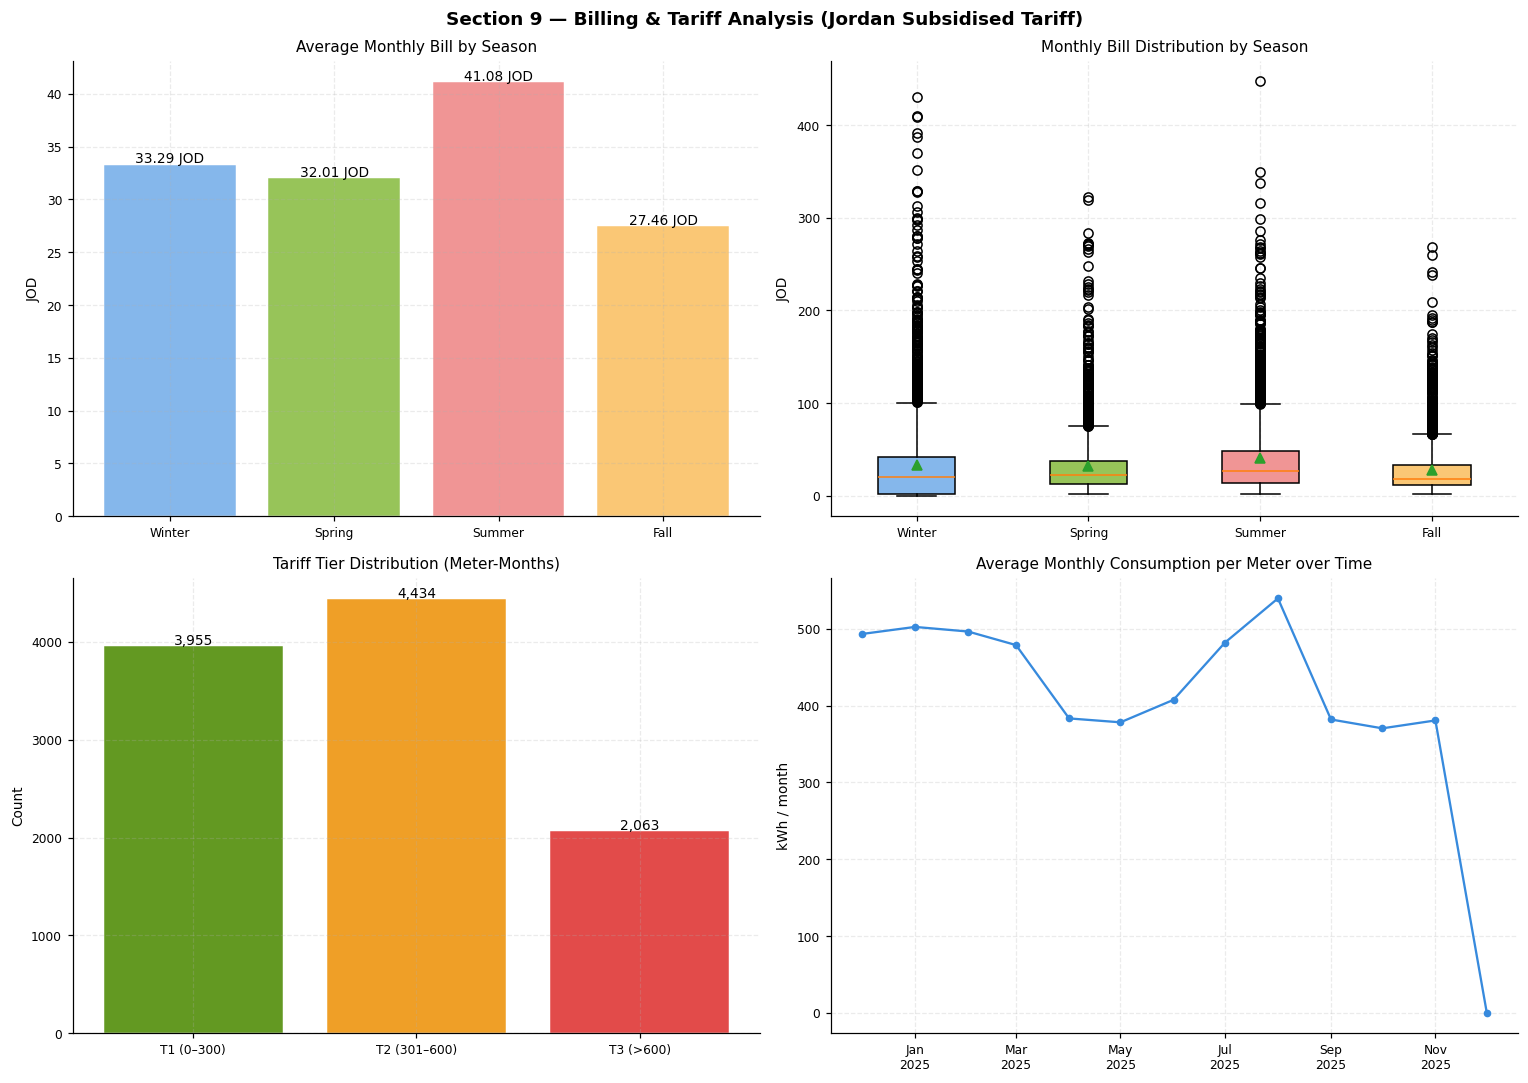


  Mean bill   : 33.45 JOD
  Median bill : 21.84 JOD
  Max bill    : 447.38 JOD
  T1 (0–300):  3,955  (37.8%)
  T2 (301–600):  4,434  (42.4%)
  T3 (>600):  2,063  (19.7%)


In [16]:
# =============================================================================
# SECTION 9 — Billing & tariff analysis
# =============================================================================

print("\n" + "=" * 60)
print("SECTION 9 — Billing & Tariff Analysis")
print("=" * 60)

def tier_label(kwh):
    if kwh <= 300: return "T1 (0–300)"
    if kwh <= 600: return "T2 (301–600)"
    return               "T3 (>600)"

def get_season(p):
    m = p.month
    if m in [12,1,2]: return "Winter"
    if m in [3,4,5]:  return "Spring"
    if m in [6,7,8]:  return "Summer"
    return "Fall"

df_grid["_ym"] = df_grid["freeze_date"].dt.to_period("M")
monthly_bill = (df_grid.groupby(["meter_B","_ym"])
                       .agg(monthly_kwh=("A+KWH","sum"))
                       .reset_index())
monthly_bill["bill_jod"] = monthly_bill["monthly_kwh"].apply(calc_bill_jod)
monthly_bill["tier"]     = monthly_bill["monthly_kwh"].apply(tier_label)
monthly_bill["season"]   = monthly_bill["_ym"].apply(get_season)

season_order  = ["Winter","Spring","Summer","Fall"]
season_colors = ["#85B7EB","#97C459","#F09595","#FAC775"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Section 9 — Billing & Tariff Analysis (Jordan Subsidised Tariff)",
             fontweight="bold")

# avg bill by season
sb = monthly_bill.groupby("season")["bill_jod"].mean().reindex(season_order)
bars_s = axes[0,0].bar(season_order, sb.values, color=season_colors,
                       edgecolor="white", lw=0.3)
for b in bars_s:
    axes[0,0].text(b.get_x()+b.get_width()/2, b.get_height()+0.2,
                   f"{b.get_height():.2f} JOD", ha="center", fontsize=9)
axes[0,0].set_title("Average Monthly Bill by Season")
axes[0,0].set_ylabel("JOD")

# box by season
data_bp = [monthly_bill[monthly_bill["season"]==s]["bill_jod"].values
           for s in season_order]
bp = axes[0,1].boxplot(data_bp, labels=season_order, patch_artist=True, showmeans=True)
for patch, col in zip(bp["boxes"], season_colors):
    patch.set_facecolor(col)
axes[0,1].set_title("Monthly Bill Distribution by Season")
axes[0,1].set_ylabel("JOD")

# tier distribution
tier_order = ["T1 (0–300)","T2 (301–600)","T3 (>600)"]
tc = monthly_bill["tier"].value_counts()
bars_t = axes[1,0].bar(
    [t for t in tier_order if t in tc.index],
    [tc.get(t,0) for t in tier_order if t in tc.index],
    color=[C_GREEN,C_AMBER,C_RED][:sum(t in tc.index for t in tier_order)],
    edgecolor="white", lw=0.3)
for b in bars_t:
    axes[1,0].text(b.get_x()+b.get_width()/2, b.get_height()+20,
                   f"{int(b.get_height()):,}", ha="center", fontsize=9)
axes[1,0].set_title("Tariff Tier Distribution (Meter-Months)")
axes[1,0].set_ylabel("Count")

# monthly avg consumption over time
ma_t = monthly_bill.groupby("_ym")["monthly_kwh"].mean().reset_index()
ma_t["date"] = ma_t["_ym"].dt.to_timestamp()
axes[1,1].plot(ma_t["date"], ma_t["monthly_kwh"],
               lw=1.5, color=C_BLUE, marker="o", markersize=4)
axes[1,1].set_title("Average Monthly Consumption per Meter over Time")
axes[1,1].set_ylabel("kWh / month")
axes[1,1].xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
plt.setp(axes[1,1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

print(f"\n  Mean bill   : {monthly_bill['bill_jod'].mean():.2f} JOD")
print(f"  Median bill : {monthly_bill['bill_jod'].median():.2f} JOD")
print(f"  Max bill    : {monthly_bill['bill_jod'].max():.2f} JOD")
for t in tier_order:
    n = tc.get(t, 0)
    print(f"  {t}: {n:>6,}  ({n/len(monthly_bill)*100:.1f}%)")

df_grid.drop(columns=["_ym"], inplace=True, errors="ignore")


SECTION 10 — Feature Engineering
  Features added: 28 total columns
  Columns: ['meter_B', 'freeze_date', 'A+KWH', 'is_imputed', 'is_imputed_linear', 'is_imputed_seasonal', 'is_imputed_knn', 'slot_sin', 'slot_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'year_sin', 'year_cos', 'is_weekend', 'is_business_hour', 'is_ramadan', 'area_load_lag_48', 'area_load_roll_mean_336', 'lag_1', 'lag_48', 'lag_336', 'roll_mean_48', 'roll_std_48', 'roll_mean_336', 'cumkwh_in_month', 'billing_tier']


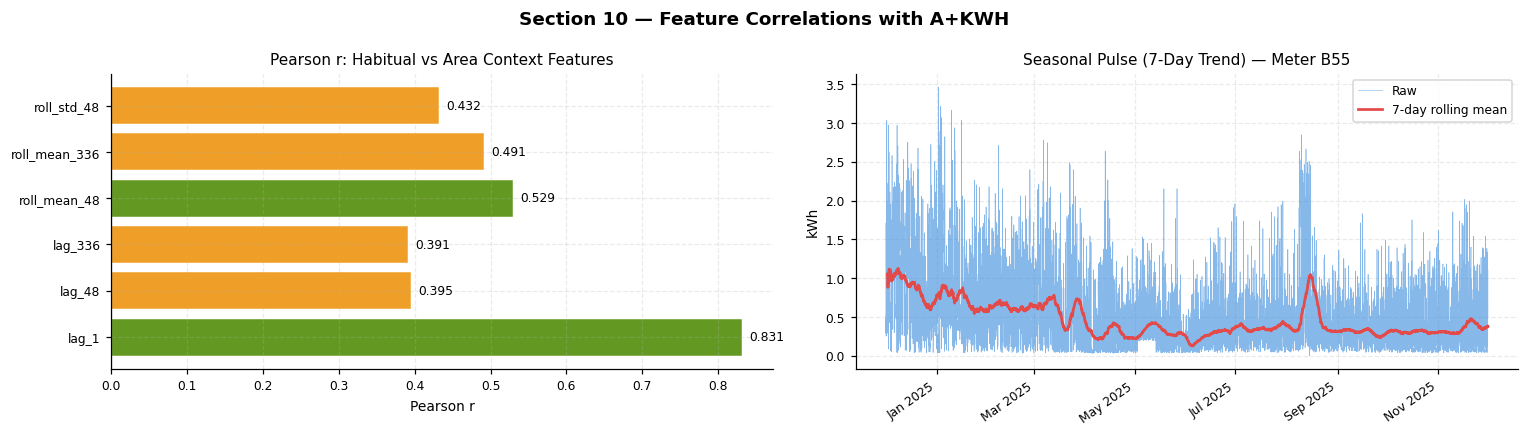

In [17]:
# =============================================================================
# SECTION 10 — Feature engineering
# =============================================================================

print("\n" + "=" * 60)
print("SECTION 10 — Feature Engineering")
print("=" * 60)

df_grid = df_grid.sort_values(["meter_B","freeze_date"]).copy()
fd   = df_grid["freeze_date"]
slot = fd.dt.hour * 2 + (fd.dt.minute == 30).astype(int)

# 1. Cyclical Time Features
# Time of day (24h cycle)
df_grid["slot_sin"]  = np.sin(2*np.pi*slot/48).astype("float32")
df_grid["slot_cos"]  = np.cos(2*np.pi*slot/48).astype("float32")
# Day of week (7d cycle)
df_grid["dow_sin"]   = np.sin(2*np.pi*fd.dt.dayofweek/7).astype("float32")
df_grid["dow_cos"]   = np.cos(2*np.pi*fd.dt.dayofweek/7).astype("float32")
# Month (12m cycle)
df_grid["month_sin"] = np.sin(2*np.pi*(fd.dt.month-1)/12).astype("float32")
df_grid["month_cos"] = np.cos(2*np.pi*(fd.dt.month-1)/12).astype("float32")
# Year (365d cycle)
df_grid["year_sin"]  = np.sin(2*np.pi*fd.dt.dayofyear/365.25).astype("float32")
df_grid["year_cos"]  = np.cos(2*np.pi*fd.dt.dayofyear/365.25).astype("float32")

# 2. Calendar Flags
df_grid["is_weekend"] = fd.dt.dayofweek.isin([4,5]).astype("int8")
df_grid["is_business_hour"] = fd.dt.hour.between(8, 15).astype("int8")
df_grid["is_ramadan"] = fd.between(RAMADAN_START, RAMADAN_END).astype("int8")

# 3. Area-Level Context
# Calculate the neighborhood average per timestamp
area_avg_pulse = df_grid.groupby("freeze_date")["A+KWH"].mean().reset_index()
area_avg_pulse.columns = ["freeze_date", "area_load_instant"]
# Merge back into main grid
df_grid = pd.merge(df_grid, area_avg_pulse, on="freeze_date", how="left")
# Create the Daily Mirror (24h ago)
df_grid["area_load_lag_48"] = df_grid.groupby("meter_B")["area_load_instant"].shift(48).astype("float32")
# Create the Seasonal Anchor (7-day area rolling mean)
# We use shift(48) first to ensure the model only sees data from the past
df_grid["area_load_roll_mean_336"] = df_grid.groupby("meter_B")["area_load_instant"].transform(
    lambda x: x.shift(48).rolling(window=336, min_periods=48).mean()
).astype("float32")
# Cleanup to avoid Data Leakage
df_grid.drop(columns=["area_load_instant"], inplace=True)

# 4. Individual Lags & Rolling Statistics
grp = df_grid.groupby("meter_B")["A+KWH"]
df_grid["lag_1"]         = grp.shift(1).astype("float32")
df_grid["lag_48"]        = grp.shift(48).astype("float32")
df_grid["lag_336"]       = grp.shift(336).astype("float32")
df_grid["roll_mean_48"]  = grp.transform(lambda s: s.rolling(48,  min_periods=12).mean()).astype("float32")
df_grid["roll_std_48"]   = grp.transform(lambda s: s.rolling(48,  min_periods=12).std()).astype("float32")
df_grid["roll_mean_336"] = grp.transform(lambda s: s.rolling(336, min_periods=48).mean()).astype("float32")

# 5. Billing Features
df_grid["_ym"] = fd.dt.to_period("M")
df_grid["cumkwh_in_month"] = df_grid.groupby(["meter_B","_ym"])["A+KWH"].cumsum().astype("float32")
df_grid["billing_tier"]    = pd.cut(df_grid["cumkwh_in_month"],
                                     bins=[-1,300,600,float("inf")],
                                     labels=[0,1,2]).astype("int8")
df_grid.drop(columns=["_ym"], inplace=True)

print(f"  Features added: {df_grid.shape[1]} total columns")
print(f"  Columns: {list(df_grid.columns)}")

# ── lag/context correlation bar chart ─────────────────────────────────
lag_names = ["lag_1","lag_48","lag_336","roll_mean_48","roll_mean_336","roll_std_48"]
lag_corrs = []
for l in lag_names:
    sub = df_grid[["A+KWH",l]].dropna()
    lag_corrs.append(sub["A+KWH"].corr(sub[l]) if len(sub) > 100 else 0.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Section 10 — Feature Correlations with A+KWH", fontweight="bold")

colors_lag = [C_GREEN if c > 0.5 else C_AMBER if c > 0.3 else C_RED for c in lag_corrs]
axes[0].barh(lag_names, lag_corrs, color=colors_lag, edgecolor="white", lw=0.3)
axes[0].axvline(0, color=C_GRAY, lw=0.8)
for i, v in enumerate(lag_corrs):
    axes[0].text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=8)
axes[0].set_title("Pearson r: Habitual vs Area Context Features")
axes[0].set_xlabel("Pearson r")

# sample meter rolling mean vs raw
sample_m  = df_grid["meter_B"].unique()[len(df_grid["meter_B"].unique())//2]
sm        = df_grid[df_grid["meter_B"]==sample_m].sort_values("freeze_date")
axes[1].plot(sm["freeze_date"], sm["A+KWH"], lw=0.4, color=C_BLUE, alpha=0.6, label="Raw")
axes[1].plot(sm["freeze_date"], sm["roll_mean_336"], lw=1.8, color=C_RED, label="7-day rolling mean")
axes[1].set_title(f"Seasonal Pulse (7-Day Trend) — Meter {sample_m}")
axes[1].set_ylabel("kWh")
axes[1].legend()
_fmt_xaxis(axes[1])

plt.tight_layout()
plt.show()

In [18]:
# =============================================================================
# Feature Engineering Summary
# =============================================================================
# This section creates model-ready features from time-series electricity data.
#
# 1. Cyclical Time Features:
#    - slot_sin, slot_cos -> encode time of day (30-min slots, 24h cycle)
#    - dow_sin, dow_cos   -> encode day of week (weekly pattern)
#    - month_sin, month_cos -> encode seasonality (monthly pattern)
#    - year_sin, year_cos -> encode annual seasonality (365-day continuous cycle)
#    -> These capture periodic behavior at different temporal scales in electricity usage
#
# 2. Calendar Features:
#    - is_weekend -> different usage on weekends (Fri–Sat)
#    - is_ramadan -> shifted daily patterns (high night activity)
#    - is_business_hour -> standard working window (08:00–16:00); captures occupancy shifts
#
# 3. Lag Features (historical memory):
#    - lag_1   -> previous 30-min consumption (short-term continuity)
#    - lag_48  -> same time yesterday (daily pattern)
#    - lag_336 -> same time last week (weekly pattern)
#
# 4. Rolling Statistics (trend & variability):
#    - roll_mean_48   -> 1-day average (smooth daily trend)
#    - roll_std_48    -> 1-day variability (stability vs fluctuation)
#    - roll_mean_336  -> 7-day average (long-term consumption level)
#
# 5. Billing Features:
#    - cumkwh_in_month -> cumulative monthly usage (simulates billing accumulation)
#    - billing_tier    -> tariff category (0: ≤300, 1: ≤600, 2: >600 kWh)
#    -> Captures behavioral changes due to pricing thresholds.
#
# 6. Area Context:
#    - area_load_lag_48 -> The total neighborhood consumption exactly 24h ago
#    - area_load_roll_mean_336 -> The 7-day moving average of the entire area
#    -> High area load indicates extreme weather (AC/Heating) without needing
#       external weather sensors.
#    -> Helps the model distinguish between individual house noise and
#       neighborhood-wide trends.
#
# Overall: Features combine time patterns, user behavior, historical memory,
# and economic signals to improve forecasting performance.
# =============================================================================

In [19]:
# =============================================================================
# SECTION 11 — Drop warmup rows (first 7 days per meter)
# lag_336 = 7-day lag; first 336 slots per meter are NaN or partial.
# We drop the first 7 days (336 half-hour slots) per meter so every row
# has valid lag_336 and roll_mean_336 values before scaling or modelling.
# =============================================================================

print("=" * 65)
print("SECTION 11 — Drop first 7 days (warmup for lags & rolling stats)")
print("=" * 65)

rows_before = len(df_grid)

# rank each row within its meter by time order
df_grid = df_grid.sort_values(["meter_B", "freeze_date"]).copy()
df_grid["_rank"] = df_grid.groupby("meter_B").cumcount()
df_grid = df_grid[df_grid["_rank"] >= 336].drop(columns=["_rank"])
df_grid = df_grid.reset_index(drop=True)

rows_after = len(df_grid)
print(f"  Rows before trim : {rows_before:,}")
print(f"  Rows dropped     : {rows_before - rows_after:,}  (7 days × {rows_before // 336 // 2} meters est.)")
print(f"  Rows after trim  : {rows_after:,}")
print(f"  NaN in lag_336   : {df_grid['lag_336'].isna().sum()} (should be 0)")
print(f"  Date range now   : {df_grid['freeze_date'].min().date()} → {df_grid['freeze_date'].max().date()}")

SECTION 11 — Drop first 7 days (warmup for lags & rolling stats)
  Rows before trim : 14,086,080
  Rows dropped     : 270,144  (7 days × 20961 meters est.)
  Rows after trim  : 13,815,936
  NaN in lag_336   : 0 (should be 0)
  Date range now   : 2024-12-08 → 2025-12-01



SECTION 12 — Per-meter MinMax scaling
  Meters scaled    : 804
  Scaled columns   : ['A+KWH', 'lag_1', 'lag_48', 'lag_336', 'roll_mean_48', 'roll_std_48', 'roll_mean_336', 'cumkwh_in_month', 'area_load_lag_48', 'area_load_roll_mean_336']
  A+KWH range now  : [0.000, 1.000]


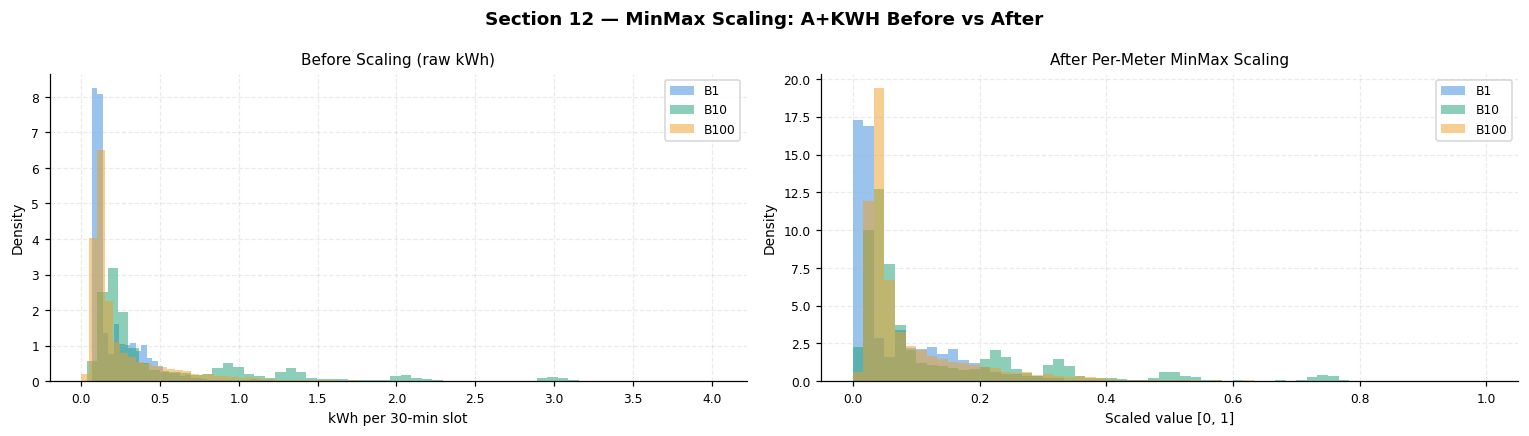


  df_scaled shape  : (13815936, 28)
  Columns          : ['meter_B', 'freeze_date', 'A+KWH', 'is_imputed', 'is_imputed_linear', 'is_imputed_seasonal', 'is_imputed_knn', 'slot_sin', 'slot_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'year_sin', 'year_cos', 'is_weekend', 'is_business_hour', 'is_ramadan', 'area_load_lag_48', 'area_load_roll_mean_336', 'lag_1', 'lag_48', 'lag_336', 'roll_mean_48', 'roll_std_48', 'roll_mean_336', 'cumkwh_in_month', 'billing_tier']


In [20]:
# =============================================================================
# SECTION 12 — Per-meter MinMax scaling on A+KWH
# =============================================================================
# We scale A+KWH (and the lag/rolling features derived from it) per meter
# so that each meter's dynamic range is normalised to [0, 1].
# All other features (cyclical, flags, billing) are already in bounded ranges.
# Scalers are saved so we can inverse-transform forecasts later.

from sklearn.preprocessing import MinMaxScaler

print("\n" + "=" * 65)
print("SECTION 12 — Per-meter MinMax scaling")
print("=" * 65)

# columns to scale: the raw target + lag/rolling features (all kWh-valued)
KWH_COLS = ["A+KWH", "lag_1", "lag_48", "lag_336",
            "roll_mean_48", "roll_std_48", "roll_mean_336", "cumkwh_in_month",
            "area_load_lag_48","area_load_roll_mean_336"]

scalers = {}   # meter_id -> fitted MinMaxScaler (on A+KWH only)
parts   = []

for mid, grp in df_grid.groupby("meter_B", sort=False):
    g  = grp.copy()
    sc = MinMaxScaler()
    # fit on A+KWH only so we can invert-transform forecasts cleanly
    sc.fit(g[["A+KWH"]])
    scalers[mid] = sc
    # scale all kWh-valued columns with the same per-meter scale
    # (uses the same min/max so relative patterns are preserved)
    sc_full = MinMaxScaler()
    sc_full.fit(g[KWH_COLS])
    g[KWH_COLS] = sc_full.transform(g[KWH_COLS]).astype("float32")
    parts.append(g)

df_scaled = pd.concat(parts, ignore_index=True)
df_scaled = df_scaled.sort_values(["meter_B", "freeze_date"]).reset_index(drop=True)

print(f"  Meters scaled    : {len(scalers)}")
print(f"  Scaled columns   : {KWH_COLS}")
print(f"  A+KWH range now  : [{df_scaled['A+KWH'].min():.3f}, {df_scaled['A+KWH'].max():.3f}]")

# ── plot: distribution before vs after scaling (sample 3 meters) ─────────────
sample_meters = df_grid["meter_B"].unique()[:3]
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Section 12 — MinMax Scaling: A+KWH Before vs After", fontweight="bold")

for mid, col in zip(sample_meters, [C_BLUE, C_TEAL, C_AMBER]):
    raw_vals = df_grid[df_grid["meter_B"] == mid]["A+KWH"]
    axes[0].hist(raw_vals, bins=60, alpha=0.5, color=col, label=mid, density=True)
    sc_vals  = df_scaled[df_scaled["meter_B"] == mid]["A+KWH"]
    axes[1].hist(sc_vals,  bins=60, alpha=0.5, color=col, label=mid, density=True)

axes[0].set_title("Before Scaling (raw kWh)")
axes[0].set_xlabel("kWh per 30-min slot")
axes[0].set_ylabel("Density")
axes[0].legend()

axes[1].set_title("After Per-Meter MinMax Scaling")
axes[1].set_xlabel("Scaled value [0, 1]")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n  df_scaled shape  : {df_scaled.shape}")
print(f"  Columns          : {list(df_scaled.columns)}")

In [21]:
# =============================================================================
# SECTION 13 — 6-Fold Walk-Forward Validation
# =============================================================================
# Columns: meter_B, freeze_date, A+KWH, is_imputed_*, slot_sin/cos, dow_sin/cos,
#          month_sin/cos, is_weekend, is_ramadan, is_business_hour, lag_1, lag_48, lag_336,
#          roll_mean_48, roll_std_48, roll_mean_336, cumkwh_in_month, billing_tier,
#          area_load_lag_48, area_load_roll_mean_336
#
#  Fold  Train window          Val       Test      Focus
#  1     Dec 8 – Apr 30        May 25    Jun 25    Start of Summer
#  2     Dec 8 – May 31        Jun 25    Jul 25    High Summer Heat
#  3     Dec 8 – Jun 30        Jul 25    Aug 25    Peak AC Load
#  4     Dec 8 – Jul 31        Aug 25    Sep 25    Autumn Transition
#  5     Dec 8 – Aug 31        Sep 25    Oct 25    Moderate Weather
#  6     Dec 8 – Sep 30        Oct 25    Nov 25    Winter Heating Start
#
# Training always starts from the earliest available date (after warmup trim).
# Validation = tuning month immediately after train end.
# Test = evaluation month immediately after val end.

print("\n" + "=" * 60)
print("SECTION 13 — 6-Fold Walk-Forward Validation")
print("=" * 60)

FOLDS = [
    # (train_end,   val_start,  val_end,    test_start, test_end,   focus)
    ("2025-04-30", "2025-05-01", "2025-05-31", "2025-06-01", "2025-06-30"),
    ("2025-05-31", "2025-06-01", "2025-06-30", "2025-07-01", "2025-07-31"),
    ("2025-06-30", "2025-07-01", "2025-07-31", "2025-08-01", "2025-08-31"),
    ("2025-07-31", "2025-08-01", "2025-08-31", "2025-09-01", "2025-09-30"),
    ("2025-08-31", "2025-09-01", "2025-09-30", "2025-10-01", "2025-10-31"),
    ("2025-09-30", "2025-10-01", "2025-10-31", "2025-11-01", "2025-11-30"),
]

folds_out = []   # list of dicts with (fold, df_train, df_val, df_test)

for i, (tr_end, va_s, va_e, te_s, te_e) in enumerate(FOLDS):
    tr_end = pd.Timestamp(tr_end)
    va_s   = pd.Timestamp(va_s);  va_e = pd.Timestamp(va_e) + pd.Timedelta("23h30m")
    te_s   = pd.Timestamp(te_s);  te_e = pd.Timestamp(te_e) + pd.Timedelta("23h30m")

    df_train = df_scaled[df_scaled["freeze_date"] <= tr_end].copy()
    df_val   = df_scaled[(df_scaled["freeze_date"] >= va_s) &
                         (df_scaled["freeze_date"] <= va_e)].copy()
    df_test  = df_scaled[(df_scaled["freeze_date"] >= te_s) &
                         (df_scaled["freeze_date"] <= te_e)].copy()

    folds_out.append({"fold": i+1,
                      "train": df_train, "val": df_val, "test": df_test})

    print(f"\n  FOLD {i+1}")
    print(f"    Train : {df_train['freeze_date'].min().date()} → {df_train['freeze_date'].max().date()}  ({len(df_train):,} rows)")
    print(f"    Val   : {df_val['freeze_date'].min().date()}   → {df_val['freeze_date'].max().date()}  ({len(df_val):,} rows)")
    print(f"    Test  : {df_test['freeze_date'].min().date()}  → {df_test['freeze_date'].max().date()}  ({len(df_test):,} rows)")


SECTION 13 — 6-Fold Walk-Forward Validation

  FOLD 1
    Train : 2024-12-08 → 2025-04-30  (5,518,656 rows)
    Val   : 2025-05-01   → 2025-05-31  (1,196,352 rows)
    Test  : 2025-06-01  → 2025-06-30  (1,157,760 rows)

  FOLD 2
    Train : 2024-12-08 → 2025-05-31  (6,715,008 rows)
    Val   : 2025-06-01   → 2025-06-30  (1,157,760 rows)
    Test  : 2025-07-01  → 2025-07-31  (1,196,352 rows)

  FOLD 3
    Train : 2024-12-08 → 2025-06-30  (7,872,768 rows)
    Val   : 2025-07-01   → 2025-07-31  (1,196,352 rows)
    Test  : 2025-08-01  → 2025-08-31  (1,196,352 rows)

  FOLD 4
    Train : 2024-12-08 → 2025-07-31  (9,069,120 rows)
    Val   : 2025-08-01   → 2025-08-31  (1,196,352 rows)
    Test  : 2025-09-01  → 2025-09-30  (1,157,760 rows)

  FOLD 5
    Train : 2024-12-08 → 2025-08-31  (10,265,472 rows)
    Val   : 2025-09-01   → 2025-09-30  (1,157,760 rows)
    Test  : 2025-10-01  → 2025-10-31  (1,196,352 rows)

  FOLD 6
    Train : 2024-12-08 → 2025-09-30  (11,423,232 rows)
    Val   : 20


SECTION 14 — Walk-Forward Split Visualisations


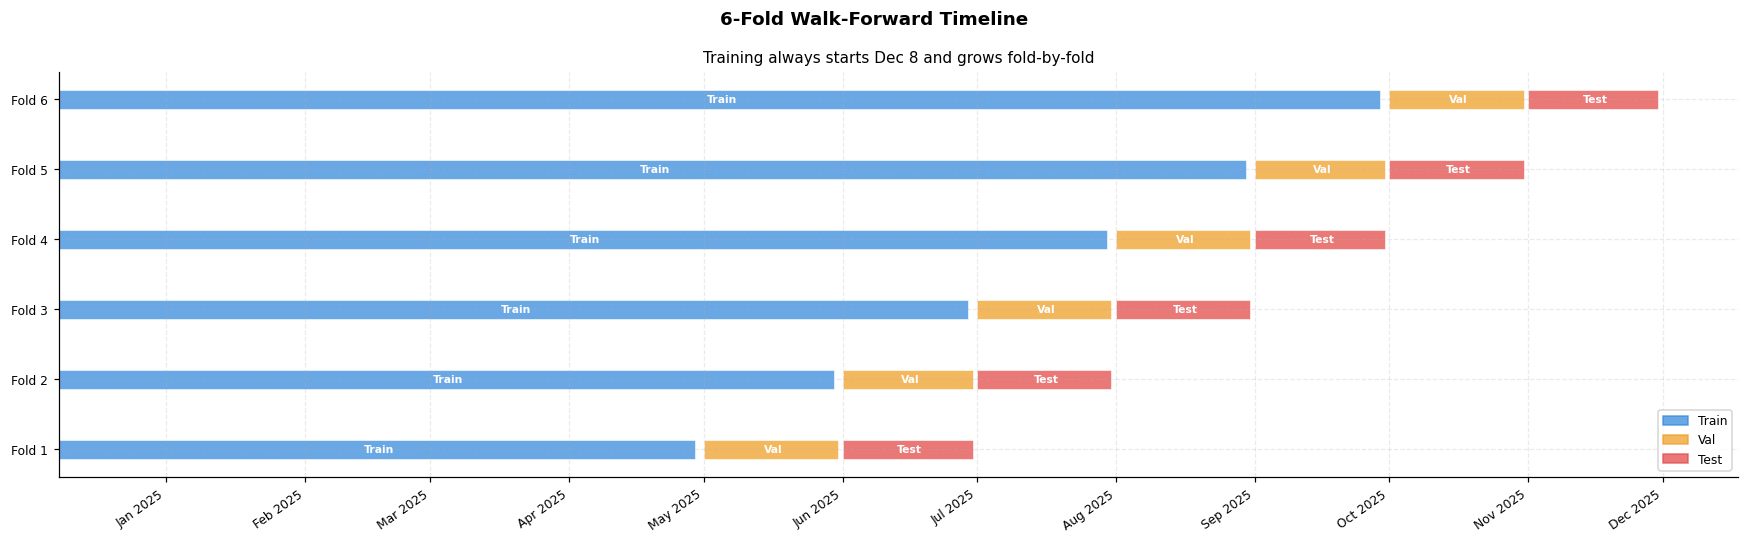

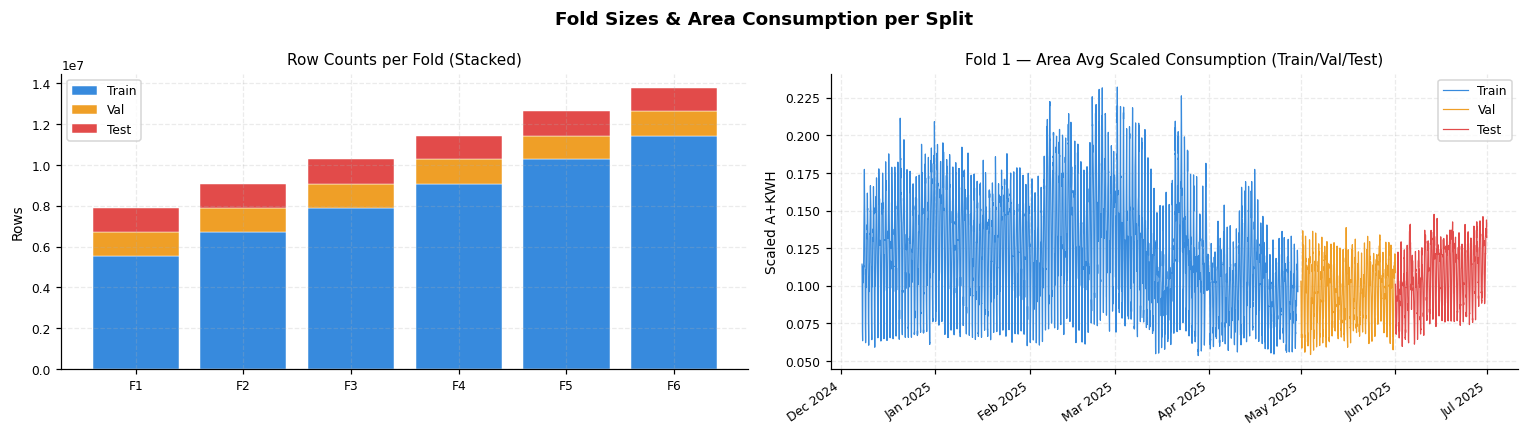

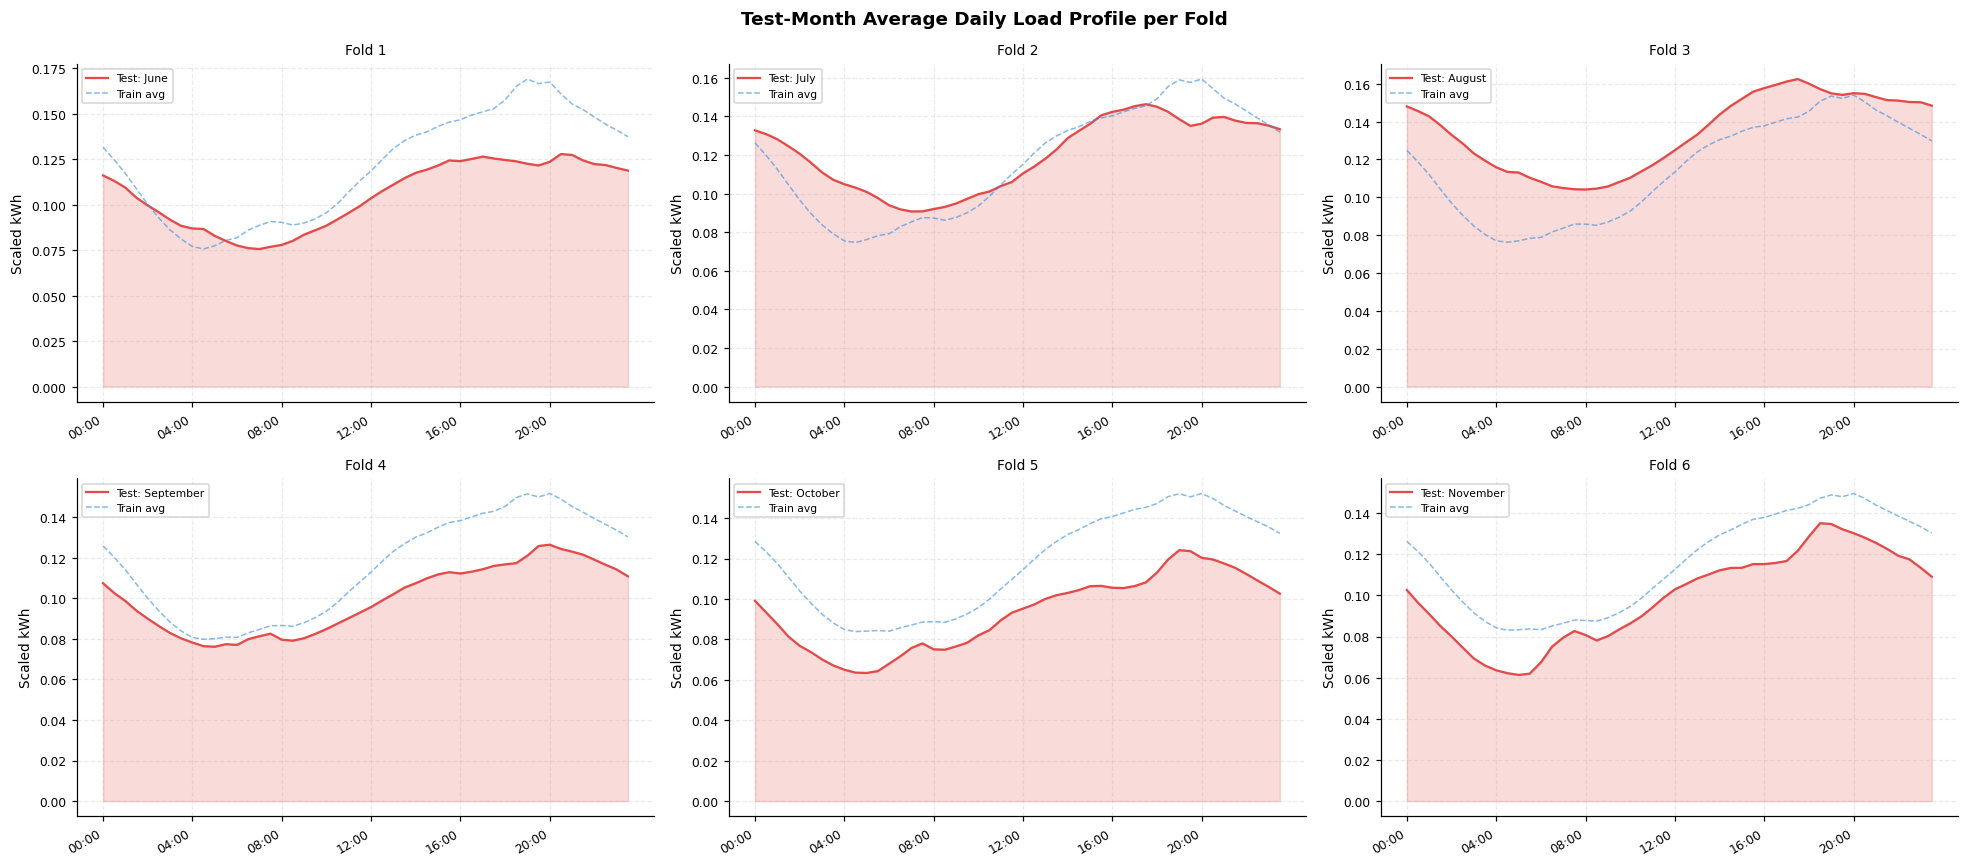

In [24]:


# =============================================================================
# SECTION 14 — Walk-forward visualisations
# =============================================================================

print("\n" + "=" * 65)
print("SECTION 14 — Walk-Forward Split Visualisations")
print("=" * 65)

# ── Fig 1: Gantt-style timeline of all 6 folds ───────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
fig.suptitle("6-Fold Walk-Forward Timeline", fontweight="bold")

fold_colors = {"Train": C_BLUE, "Val": C_AMBER, "Test": C_RED}
ytick_labels = []

for i, fd_dict in enumerate(folds_out):
    y = i * 3
    ytick_labels.append(f"Fold {fd_dict['fold']}")
    for split, col, h in [("train", C_BLUE, 0.8), ("val", C_AMBER, 0.8), ("test", C_RED, 0.8)]:
        d = fd_dict[split]["freeze_date"]
        s, e = d.min(), d.max()
        ax.barh(y, (e - s).days, left=s, height=h, color=col, alpha=0.75, edgecolor="white", lw=0.5)
        mid_x = s + (e - s) / 2
        ax.text(mid_x, y, split.capitalize(), ha="center", va="center",
                fontsize=7, color="white", fontweight="bold")

ax.set_yticks([i * 3 for i in range(len(folds_out))])
ax.set_yticklabels(ytick_labels, fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax.get_xticklabels(), rotation=35, ha="right")
legend_patches = [mpatches.Patch(color=c, alpha=0.75, label=l)
                  for l, c in fold_colors.items()]
ax.legend(handles=legend_patches, loc="lower right")
ax.set_title("Training always starts Dec 8 and grows fold-by-fold")
plt.tight_layout()
plt.show()

# ── Fig 2: Row counts per fold (stacked bar) ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Fold Sizes & Area Consumption per Split", fontweight="bold")

fold_labels = [f"F{d['fold']}" for d in folds_out]
tr_sizes = [len(d["train"]) for d in folds_out]
va_sizes = [len(d["val"])   for d in folds_out]
te_sizes = [len(d["test"])  for d in folds_out]
x = range(len(folds_out))

axes[0].bar(x, tr_sizes, color=C_BLUE,  label="Train", edgecolor="white", lw=0.3)
axes[0].bar(x, va_sizes, bottom=tr_sizes, color=C_AMBER, label="Val",   edgecolor="white", lw=0.3)
bot = [a+b for a,b in zip(tr_sizes, va_sizes)]
axes[0].bar(x, te_sizes, bottom=bot, color=C_RED, label="Test",  edgecolor="white", lw=0.3)
axes[0].set_xticks(x)
axes[0].set_xticklabels(fold_labels)
axes[0].set_title("Row Counts per Fold (Stacked)")
axes[0].set_ylabel("Rows")
axes[0].legend()

# ── Fig 3: Area avg consumption coloured by split for fold 1 ─────────────────
fd1 = folds_out[0]
for split, lbl, col in [("train","Train",C_BLUE),("val","Val",C_AMBER),("test","Test",C_RED)]:
    area = fd1[split].groupby("freeze_date")["A+KWH"].mean()
    axes[1].plot(area.index, area.values, lw=0.8, label=lbl, color=col)
axes[1].set_title("Fold 1 — Area Avg Scaled Consumption (Train/Val/Test)")
axes[1].set_ylabel("Scaled A+KWH")
axes[1].legend()
_fmt_xaxis(axes[1])
plt.tight_layout()
plt.show()

# ── Fig 4: Test-month load profile for each fold ──────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
fig.suptitle("Test-Month Average Daily Load Profile per Fold", fontweight="bold")
axes = axes.flatten()
slot_labels_short = [f"{h:02d}:00" for h in range(0, 24, 4)]

for i, fd_dict in enumerate(folds_out):
    ax = axes[i]
    df_t = fd_dict["test"]
    sc = df_t["freeze_date"].dt.hour*2 + (df_t["freeze_date"].dt.minute==30).astype(int)
    curve = df_t.groupby(sc)["A+KWH"].mean()
    ax.fill_between(range(48), curve.reindex(range(48), fill_value=0).values,
                    alpha=0.2, color=C_RED)
    ax.plot(range(48), curve.reindex(range(48), fill_value=0).values,
            color=C_RED, lw=1.5, label=f"Test: {df_t['freeze_date'].dt.month_name().iloc[0]}")
    # overlay train for comparison
    df_tr = fd_dict["train"]
    sc_tr = df_tr["freeze_date"].dt.hour*2 + (df_tr["freeze_date"].dt.minute==30).astype(int)
    curve_tr = df_tr.groupby(sc_tr)["A+KWH"].mean()
    ax.plot(range(48), curve_tr.reindex(range(48), fill_value=0).values,
            color=C_BLUE, lw=1, ls="--", alpha=0.6, label="Train avg")
    ax.set_xticks(range(0, 48, 8))
    ax.set_xticklabels([f"{h:02d}:00" for h in range(0, 24, 4)], rotation=30, ha="right")
    ax.set_title(f"Fold {fd_dict['fold']}", fontsize=9)
    ax.set_ylabel("Scaled kWh")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

In [25]:
# =============================================================================
# SECTION 15 — Save all splits to CSV (download cell)
# Files written to ./splits/ — download from there as needed.
# Each fold: train, val, test  →  18 files total + df_scaled (full)
# =============================================================================

print("\n" + "=" * 65)
print("SECTION 15 — Save Splits to CSV")
print("=" * 65)

os.makedirs("splits", exist_ok=True)

# save full scaled dataset
df_scaled.to_csv("splits/df_scaled_full.csv", index=False)
print(f"  Saved: splits/df_scaled_full.csv  ({len(df_scaled):,} rows)")

# save per-fold splits
for fd_dict in folds_out:
    f = fd_dict["fold"]
    for split in ("train", "val", "test"):
        fname = f"splits/fold{f}_{split}.csv"
        fd_dict[split].to_csv(fname, index=False)
        print(f"  Saved: {fname}  ({len(fd_dict[split]):,} rows)")

print(f"\n  Total files saved : {1 + 6*3}")
print(f"  Output folder     : ./splits/")


SECTION 15 — Save Splits to CSV
  Saved: splits/df_scaled_full.csv  (13,815,936 rows)
  Saved: splits/fold1_train.csv  (5,518,656 rows)
  Saved: splits/fold1_val.csv  (1,196,352 rows)
  Saved: splits/fold1_test.csv  (1,157,760 rows)
  Saved: splits/fold2_train.csv  (6,715,008 rows)
  Saved: splits/fold2_val.csv  (1,157,760 rows)
  Saved: splits/fold2_test.csv  (1,196,352 rows)
  Saved: splits/fold3_train.csv  (7,872,768 rows)
  Saved: splits/fold3_val.csv  (1,196,352 rows)
  Saved: splits/fold3_test.csv  (1,196,352 rows)
  Saved: splits/fold4_train.csv  (9,069,120 rows)
  Saved: splits/fold4_val.csv  (1,196,352 rows)
  Saved: splits/fold4_test.csv  (1,157,760 rows)
  Saved: splits/fold5_train.csv  (10,265,472 rows)
  Saved: splits/fold5_val.csv  (1,157,760 rows)
  Saved: splits/fold5_test.csv  (1,196,352 rows)
  Saved: splits/fold6_train.csv  (11,423,232 rows)
  Saved: splits/fold6_val.csv  (1,196,352 rows)
  Saved: splits/fold6_test.csv  (1,157,760 rows)

  Total files saved : 19
  O

In [27]:
# ── quick preview table ───────────────────────────────────────────────────────
print("\n  ── Fold summary ──────────────────────────────────────────────────")
print(f"  {'Fold':<6} {'Train rows':>11} {'Val rows':>9} {'Test rows':>10}")
print(f"  {'─'*6} {'─'*11} {'─'*9} {'─'*10}")
for fd_dict in folds_out:
    print(f"  {fd_dict['fold']:<6} "
          f"{len(fd_dict['train']):>11,} {len(fd_dict['val']):>9,} {len(fd_dict['test']):>10,}")

print("\n  To load a specific split in another notebook:")
print("    import pandas as pd")
print("    df_train = pd.read_csv('splits/fold1_train.csv', parse_dates=['freeze_date'])")
print("    df_val   = pd.read_csv('splits/fold1_val.csv',   parse_dates=['freeze_date'])")
print("    df_test  = pd.read_csv('splits/fold1_test.csv',  parse_dates=['freeze_date'])")

print("\n" + "=" * 65)
print("PART B COMPLETE  —  df_scaled, scalers, folds_out ready for LSTM")
print("=" * 65)


  ── Fold summary ──────────────────────────────────────────────────
  Fold    Train rows  Val rows  Test rows
  ────── ─────────── ───────── ──────────
  1        5,518,656 1,196,352  1,157,760
  2        6,715,008 1,157,760  1,196,352
  3        7,872,768 1,196,352  1,196,352
  4        9,069,120 1,196,352  1,157,760
  5       10,265,472 1,157,760  1,196,352
  6       11,423,232 1,196,352  1,157,760

  To load a specific split in another notebook:
    import pandas as pd
    df_train = pd.read_csv('splits/fold1_train.csv', parse_dates=['freeze_date'])
    df_val   = pd.read_csv('splits/fold1_val.csv',   parse_dates=['freeze_date'])
    df_test  = pd.read_csv('splits/fold1_test.csv',  parse_dates=['freeze_date'])

PART B COMPLETE  —  df_scaled, scalers, folds_out ready for LSTM
